# Deep Q-Network for Atari Game Playing

## Applied Machine Intelligence Project

This project implements a Deep Q-Network (DQN) agent that learns to play an Atari game using visual observations. The implementation uses PyTorch and a Gymnasium-compatible Atari environment.

The project demonstrates the complete DQN training pipeline, including:

- Atari environment configuration and visual preprocessing
- A convolutional neural network for Q-value approximation
- Experience replay
- Online and target networks
- Epsilon-greedy exploration
- Temporal-difference learning
- Model checkpointing
- Training and evaluation metrics
- Reward, loss, and Q-value visualizations

The notebook is designed to run in both the local `.venv_global` environment and Google Colab with minimal configuration changes.

## Project Workflow

1. Configure the local or Colab execution environment.
2. Install and verify required packages.
3. Create and inspect the Atari environment.
4. Apply observation preprocessing and frame stacking.
5. Implement the replay buffer.
6. Build the convolutional DQN architecture.
7. Implement epsilon-greedy action selection.
8. Configure the online and target networks.
9. Train the DQN agent.
10. Evaluate the trained agent and visualize performance.

## 1. Runtime and Dependency Diagnostics

Before configuring the Atari environment, this section verifies the Python interpreter, execution platform, working directory, PyTorch device, and required package versions.

Running these diagnostics first helps ensure that the notebook is using the intended `.venv_global` environment and identifies any missing dependencies before the DQN implementation begins.

In [3]:
# Standard-library imports used for runtime diagnostics
import importlib
import importlib.metadata
import os
import platform
import sys
from pathlib import Path


def detect_runtime():
    """
    Detect whether the notebook is running locally or in Google Colab.
    """
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        return "local"


def get_package_version(package_name):
    """
    Return the installed version of a package.

    If the package is not installed, return a readable status message
    instead of stopping the notebook with an error.
    """
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return "Not installed"


runtime_environment = detect_runtime()
current_directory = Path.cwd()

print("=" * 65)
print("RUNTIME INFORMATION")
print("=" * 65)
print(f"Runtime environment : {runtime_environment}")
print(f"Operating system    : {platform.system()} {platform.release()}")
print(f"Python version      : {platform.python_version()}")
print(f"Python executable   : {sys.executable}")
print(f"Working directory   : {current_directory}")

print("\n" + "=" * 65)
print("PACKAGE VERSIONS")
print("=" * 65)

required_packages = {
    "torch": "PyTorch",
    "gymnasium": "Gymnasium",
    "ale-py": "Arcade Learning Environment",
    "numpy": "NumPy",
    "opencv-python": "OpenCV",
    "matplotlib": "Matplotlib",
    "pandas": "Pandas",
    "ipykernel": "Jupyter Kernel",
}

for package_name, display_name in required_packages.items():
    version = get_package_version(package_name)
    print(f"{display_name:<30}: {version}")

print("\n" + "=" * 65)
print("PYTORCH DEVICE INFORMATION")
print("=" * 65)

try:
    import torch

    cuda_available = torch.cuda.is_available()
    device = torch.device("cuda" if cuda_available else "cpu")

    print(f"Selected device     : {device}")
    print(f"CUDA available      : {cuda_available}")

    if cuda_available:
        print(f"CUDA version        : {torch.version.cuda}")
        print(f"GPU device          : {torch.cuda.get_device_name(0)}")
        print(f"GPU device count    : {torch.cuda.device_count()}")
    else:
        print("GPU device          : No CUDA-compatible GPU detected")

except ImportError:
    print("PyTorch is not installed.")
    device = None

print("\nDiagnostic check completed.")

RUNTIME INFORMATION
Runtime environment : local
Operating system    : Windows 10
Python version      : 3.11.9
Python executable   : c:\Users\dubey\Documents\UC_GitLab\.venv_global\Scripts\python.exe
Working directory   : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game

PACKAGE VERSIONS
PyTorch                       : 2.10.0
Gymnasium                     : 1.3.0
Arcade Learning Environment   : 0.12.0
NumPy                         : 1.26.4
OpenCV                        : 4.10.0.84
Matplotlib                    : 3.10.8
Pandas                        : 2.3.3
Jupyter Kernel                : 7.1.0

PYTORCH DEVICE INFORMATION
Selected device     : cpu
CUDA available      : False
GPU device          : No CUDA-compatible GPU detected

Diagnostic check completed.


## 2. Install Atari Environment Dependencies

The DQN project requires Gymnasium and the Arcade Learning Environment
(ALE) to simulate Atari games.

OpenCV is also required for preprocessing raw game frames. It will later
be used to resize Atari observations and convert them to grayscale.

The installation command uses the Python executable associated with the
currently selected notebook kernel. This ensures that the packages are
installed inside `.venv_global` rather than another Python environment.

In [2]:
# Install the Atari environment and image-processing dependencies
# into the Python environment used by the current notebook kernel.

import subprocess
import sys


packages_to_install = [
    "gymnasium[atari]",
    "opencv-python==4.10.0.84",
]

print("Installing packages with:")
print(sys.executable)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        *packages_to_install,
    ]
)

print("\nAtari dependencies installed successfully.")

Installing packages with:
c:\Users\dubey\Documents\UC_GitLab\.venv_global\Scripts\python.exe

Atari dependencies installed successfully.


## 3. Portable Project Configuration

This section defines the main project configuration shared by the local
`.venv_global` environment and Google Colab.

The configuration automatically detects the runtime environment and available
PyTorch device. It also creates portable paths for model checkpoints, outputs,
screenshots, and the written report.

Two primary execution profiles will be used:

- `local_test`: short runs for implementation testing and debugging
- `colab_train`: longer training runs using a GPU when available

The Atari environment selected for this project is `ALE/Breakout-v5`.

In [1]:
# Configure the notebook for both local execution and Google Colab.

from pathlib import Path
import random

import numpy as np
import torch


# ---------------------------------------------------------
# User-adjustable settings
# ---------------------------------------------------------

EXECUTION_MODE = "auto"
# Options: "auto", "local", "colab"

TRAINING_PROFILE = "auto"
# Options: "auto", "local_test", "colab_train", "evaluation"

ENVIRONMENT_ID = "ALE/Breakout-v5"
RANDOM_SEED = 42


# ---------------------------------------------------------
# Runtime detection
# ---------------------------------------------------------

def detect_runtime():
    """
    Detect whether the notebook is running locally or in Google Colab.
    """
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        return "local"


if EXECUTION_MODE == "auto":
    runtime_environment = detect_runtime()
else:
    runtime_environment = EXECUTION_MODE


# ---------------------------------------------------------
# Training-profile selection
# ---------------------------------------------------------

if TRAINING_PROFILE == "auto":
    active_profile = (
        "colab_train"
        if runtime_environment == "colab"
        else "local_test"
    )
else:
    active_profile = TRAINING_PROFILE


# ---------------------------------------------------------
# Device selection
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ---------------------------------------------------------
# Portable project paths
# ---------------------------------------------------------

if runtime_environment == "colab":
    project_root = Path("/content/Project_DQN_Atari_Game")
else:
    # The notebook is already stored in the project folder locally.
    project_root = Path.cwd()


checkpoints_directory = project_root / "checkpoints"
outputs_directory = project_root / "outputs"
screenshots_directory = project_root / "screenshots"
report_directory = project_root / "report"

project_directories = [
    checkpoints_directory,
    outputs_directory,
    screenshots_directory,
    report_directory,
]

for directory in project_directories:
    directory.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# ---------------------------------------------------------
# Display the active configuration
# ---------------------------------------------------------

print("=" * 65)
print("PROJECT CONFIGURATION")
print("=" * 65)
print(f"Runtime environment : {runtime_environment}")
print(f"Training profile    : {active_profile}")
print(f"Atari environment   : {ENVIRONMENT_ID}")
print(f"PyTorch device      : {device}")
print(f"Random seed         : {RANDOM_SEED}")
print(f"Project root        : {project_root}")

print("\nProject directories:")

for directory in project_directories:
    print(f"  {directory.name:<12}: {directory.exists()}")

print("\nPortable project configuration completed.")

PROJECT CONFIGURATION
Runtime environment : local
Training profile    : local_test
Atari environment   : ALE/Breakout-v5
PyTorch device      : cpu
Random seed         : 42
Project root        : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game

Project directories:
  checkpoints : True
  outputs     : True
  screenshots : True
  report      : True

Portable project configuration completed.


## 4. Create and Inspect the Raw Atari Environment

This section creates the raw `ALE/Breakout-v5` environment and examines its
main reinforcement-learning components.

The environment provides:

- an observation representing the current game screen,
- a discrete action space containing valid joystick actions,
- a reward after each action,
- termination and truncation signals indicating episode completion.

The raw frames are inspected before preprocessing so that the effect of
grayscale conversion, resizing, frame skipping, and frame stacking can be
understood later.

The environment is initially configured with a frame skip of one because frame
skipping will be handled explicitly by the Atari preprocessing wrapper.

In [2]:
# Create and inspect the raw Breakout environment.

import gymnasium as gym
import ale_py


# Register ALE environments with Gymnasium.
gym.register_envs(ale_py)


raw_environment = gym.make(
    ENVIRONMENT_ID,
    render_mode="rgb_array",
    frameskip=1,
    repeat_action_probability=0.0,
)


# Reset the environment to begin a new episode.
initial_observation, reset_info = raw_environment.reset(
    seed=RANDOM_SEED
)


print("=" * 65)
print("RAW ATARI ENVIRONMENT")
print("=" * 65)
print(f"Environment ID      : {ENVIRONMENT_ID}")
print(f"Observation space   : {raw_environment.observation_space}")
print(f"Action space        : {raw_environment.action_space}")
print(f"Number of actions   : {raw_environment.action_space.n}")
print(f"Observation shape   : {initial_observation.shape}")
print(f"Observation dtype   : {initial_observation.dtype}")
print(f"Minimum pixel value : {initial_observation.min()}")
print(f"Maximum pixel value : {initial_observation.max()}")

print("\nAvailable actions:")

action_meanings = raw_environment.unwrapped.get_action_meanings()

for action_index, action_name in enumerate(action_meanings):
    print(f"  {action_index}: {action_name}")


# Take one reproducible sample action.
sample_action = raw_environment.action_space.sample()

next_observation, reward, terminated, truncated, step_info = (
    raw_environment.step(sample_action)
)

print("\n" + "=" * 65)
print("SAMPLE ENVIRONMENT STEP")
print("=" * 65)
print(f"Selected action     : {sample_action}")
print(f"Action meaning      : {action_meanings[sample_action]}")
print(f"Reward received     : {reward}")
print(f"Terminated          : {terminated}")
print(f"Truncated           : {truncated}")
print(f"Next frame shape    : {next_observation.shape}")
print(f"Information keys    : {list(step_info.keys())}")


# Close the temporary inspection environment.
raw_environment.close()

print("\nRaw Atari environment inspection completed.")

RAW ATARI ENVIRONMENT
Environment ID      : ALE/Breakout-v5
Observation space   : Box(0, 255, (210, 160, 3), uint8)
Action space        : Discrete(4)
Number of actions   : 4
Observation shape   : (210, 160, 3)
Observation dtype   : uint8
Minimum pixel value : 0
Maximum pixel value : 200

Available actions:
  0: NOOP
  1: FIRE
  2: RIGHT
  3: LEFT

SAMPLE ENVIRONMENT STEP
Selected action     : 1
Action meaning      : FIRE
Reward received     : 0.0
Terminated          : False
Truncated           : False
Next frame shape    : (210, 160, 3)
Information keys    : ['lives', 'episode_frame_number', 'frame_number']

Raw Atari environment inspection completed.


## 5. Visualize the Raw Atari Observation

The Atari observation is a full-color game frame with a resolution of
210 × 160 pixels and three RGB channels.

Visualizing the raw observation helps establish a baseline before applying DQN
preprocessing. The original frame contains more visual information than the
agent needs, including color and a relatively high spatial resolution.

A copy of the raw frame is saved in the `screenshots` directory for use in the
project report.

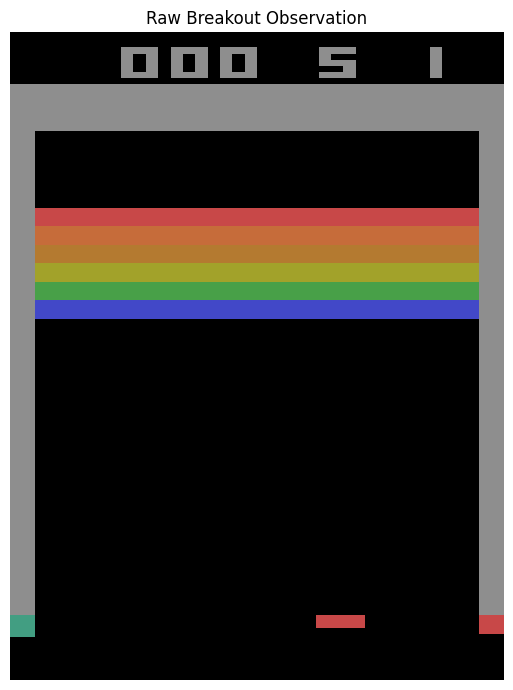

RAW FRAME OUTPUT
Frame shape         : (210, 160, 3)
Frame data type     : uint8
Screenshot saved to : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\screenshots\raw_breakout_frame.png
File exists         : True


In [3]:
# Display and save the initial raw Breakout observation.

import matplotlib.pyplot as plt


raw_frame_path = screenshots_directory / "raw_breakout_frame.png"

plt.figure(figsize=(6, 7))
plt.imshow(initial_observation)
plt.title("Raw Breakout Observation")
plt.axis("off")
plt.tight_layout()

# Save the figure before displaying it.
plt.savefig(
    raw_frame_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("=" * 65)
print("RAW FRAME OUTPUT")
print("=" * 65)
print(f"Frame shape         : {initial_observation.shape}")
print(f"Frame data type     : {initial_observation.dtype}")
print(f"Screenshot saved to : {raw_frame_path}")
print(f"File exists         : {raw_frame_path.exists()}")

## 6. Atari Observation Preprocessing

Raw Atari observations contain high-resolution RGB images that are expensive
to process and store directly.

This project applies the standard Atari preprocessing pipeline:

- random no-op actions at the beginning of an episode,
- repetition of each selected action across four emulator frames,
- max pooling to reduce visual flickering,
- grayscale conversion,
- resizing from the raw game screen to 84 × 84 pixels,
- stacking the four most recent processed frames.

Frame stacking provides the DQN with temporal information. A single frame
shows object locations, but multiple consecutive frames allow the network to
infer movement, such as the direction of the ball.

The observations remain in unsigned 8-bit format while stored in memory.
They will be normalized to the range [0, 1] only when converted into PyTorch
tensors for neural-network processing.

In [4]:
# Create a reusable Atari environment with DQN preprocessing.

from gymnasium.wrappers import (
    AtariPreprocessing,
    FrameStackObservation,
    RecordEpisodeStatistics,
)


def create_atari_environment(
    environment_id=ENVIRONMENT_ID,
    render_mode=None,
    seed=None,
):
    """
    Create a Breakout environment with standard DQN preprocessing.

    Parameters
    ----------
    environment_id : str
        Gymnasium identifier for the Atari environment.

    render_mode : str or None
        Use None for faster training and "rgb_array" when screenshots
        or videos are required.

    seed : int or None
        Optional random seed for reproducibility.

    Returns
    -------
    gym.Env
        A wrapped Atari environment producing four stacked 84 x 84
        grayscale frames.
    """

    # ALE must use frameskip=1 here because frame skipping is handled
    # explicitly by AtariPreprocessing.
    environment = gym.make(
        environment_id,
        render_mode=render_mode,
        frameskip=1,
        repeat_action_probability=0.0,
    )

    # Apply the standard Atari visual preprocessing pipeline.
    environment = AtariPreprocessing(
        environment,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        grayscale_newaxis=False,
        scale_obs=False,
    )

    # Stack the four latest grayscale frames.
    environment = FrameStackObservation(
        environment,
        stack_size=4,
        padding_type="reset",
    )

    # Track complete episode rewards and episode lengths.
    environment = RecordEpisodeStatistics(environment)

    if seed is not None:
        environment.action_space.seed(seed)

    return environment


# Create a temporary preprocessed environment for inspection.
preprocessed_environment = create_atari_environment(
    render_mode="rgb_array",
    seed=RANDOM_SEED,
)

processed_observation, processed_reset_info = (
    preprocessed_environment.reset(seed=RANDOM_SEED)
)


print("=" * 65)
print("PREPROCESSED ATARI ENVIRONMENT")
print("=" * 65)
print(
    f"Observation space   : "
    f"{preprocessed_environment.observation_space}"
)
print(
    f"Action space        : "
    f"{preprocessed_environment.action_space}"
)
print(f"Observation shape   : {processed_observation.shape}")
print(f"Observation dtype   : {processed_observation.dtype}")
print(f"Minimum pixel value : {processed_observation.min()}")
print(f"Maximum pixel value : {processed_observation.max()}")
print(f"Number of frames    : {processed_observation.shape[0]}")
print(
    f"Individual frame    : "
    f"{processed_observation.shape[1:]}"
)


# Test one valid action after preprocessing.
test_action = 1  # FIRE

(
    processed_next_observation,
    processed_reward,
    processed_terminated,
    processed_truncated,
    processed_step_info,
) = preprocessed_environment.step(test_action)


print("\n" + "=" * 65)
print("PREPROCESSED SAMPLE STEP")
print("=" * 65)
print(f"Selected action     : {test_action}")
print(f"Action meaning      : FIRE")
print(f"Reward received     : {processed_reward}")
print(f"Terminated          : {processed_terminated}")
print(f"Truncated           : {processed_truncated}")
print(
    f"Next observation    : "
    f"{processed_next_observation.shape}"
)
print(
    f"Information keys    : "
    f"{list(processed_step_info.keys())}"
)

print("\nAtari preprocessing inspection completed.")

PREPROCESSED ATARI ENVIRONMENT
Observation space   : Box(0, 255, (4, 84, 84), uint8)
Action space        : Discrete(4)
Observation shape   : (4, 84, 84)
Observation dtype   : uint8
Minimum pixel value : 0
Maximum pixel value : 148
Number of frames    : 4
Individual frame    : (84, 84)

PREPROCESSED SAMPLE STEP
Selected action     : 1
Action meaning      : FIRE
Reward received     : 0.0
Terminated          : False
Truncated           : False
Next observation    : (4, 84, 84)
Information keys    : ['lives', 'episode_frame_number', 'frame_number']

Atari preprocessing inspection completed.


## 7. Visualize the Stacked Atari Frames

The preprocessed observation contains four consecutive grayscale frames.

Each individual frame has a resolution of 84 × 84 pixels. Together, the four
frames form one DQN state with the shape `(4, 84, 84)`.

Frame stacking is important because a single image shows only the current
positions of the paddle and ball. By comparing consecutive frames, the neural
network can infer movement, including the ball's direction and speed.

The stacked frames are displayed individually and saved as a figure for later
use in the project report.

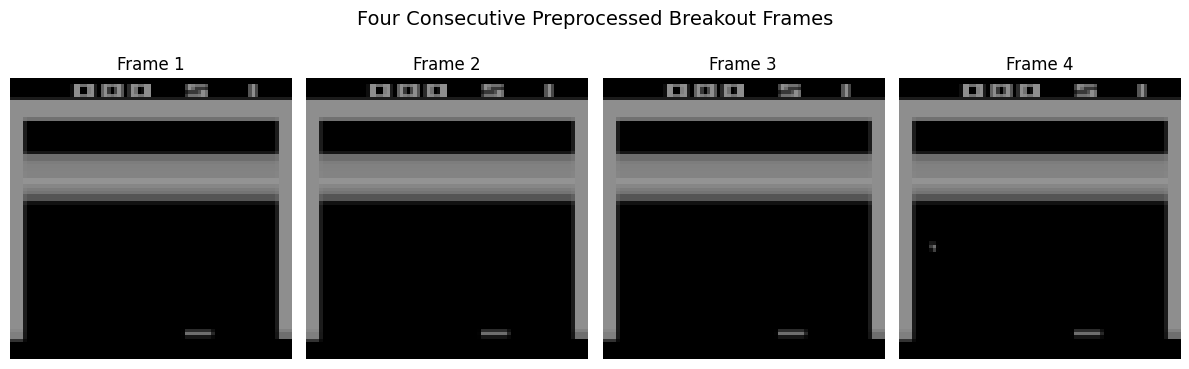

STACKED FRAME VISUALIZATION
Complete state shape : (4, 84, 84)
Number of frames     : 4
Individual frame     : (84, 84)
Data type            : uint8
Screenshot saved to  : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\screenshots\preprocessed_stacked_frames.png
File exists          : True


In [5]:
# Display and save the four frames contained in one processed observation.

stacked_frames_path = (
    screenshots_directory / "preprocessed_stacked_frames.png"
)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for frame_index, axis in enumerate(axes):
    axis.imshow(
        processed_next_observation[frame_index],
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    axis.set_title(f"Frame {frame_index + 1}")
    axis.axis("off")

fig.suptitle(
    "Four Consecutive Preprocessed Breakout Frames",
    fontsize=14,
)

plt.tight_layout()

plt.savefig(
    stacked_frames_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("=" * 65)
print("STACKED FRAME VISUALIZATION")
print("=" * 65)
print(f"Complete state shape : {processed_next_observation.shape}")
print(f"Number of frames     : {processed_next_observation.shape[0]}")
print(f"Individual frame     : {processed_next_observation.shape[1:]}")
print(f"Data type            : {processed_next_observation.dtype}")
print(f"Screenshot saved to  : {stacked_frames_path}")
print(f"File exists          : {stacked_frames_path.exists()}")

## 8. DQN Hyperparameters and Training Profiles

The DQN algorithm uses several hyperparameters that control learning,
exploration, replay-memory usage, target-network synchronization, and model
evaluation.

Two training profiles are defined:

- `local_test`: a shorter CPU-compatible run used to validate the complete
  implementation.
- `colab_train`: a longer run intended for GPU execution in Google Colab.

The number of training steps refers to actions selected by the agent after
preprocessing. Since every selected action is repeated for four emulator
frames, the approximate number of raw Atari frames is four times the number
of environment steps.

The replay buffer stores observations as unsigned 8-bit arrays to reduce
memory consumption. Observations are converted to floating-point tensors and
normalized only when sampled for neural-network training.

In [6]:
# Define the DQN hyperparameters for local testing and Colab training.

from dataclasses import asdict, dataclass
from typing import Dict


@dataclass
class DQNConfig:
    """
    Configuration values used by the DQN training pipeline.
    """

    # Core reinforcement-learning settings
    learning_rate: float
    discount_factor: float
    batch_size: int

    # Replay-buffer settings
    replay_capacity: int
    learning_starts: int
    train_frequency: int

    # Target-network settings
    target_update_frequency: int

    # Epsilon-greedy exploration settings
    epsilon_start: float
    epsilon_end: float
    epsilon_decay_steps: int

    # Training and evaluation settings
    total_environment_steps: int
    evaluation_frequency: int
    evaluation_episodes: int
    checkpoint_frequency: int

    # Optimization stability
    gradient_clip_norm: float


TRAINING_PROFILES: Dict[str, DQNConfig] = {
    "local_test": DQNConfig(
        learning_rate=1e-4,
        discount_factor=0.99,
        batch_size=32,
        replay_capacity=5_000,
        learning_starts=1_000,
        train_frequency=4,
        target_update_frequency=1_000,
        epsilon_start=1.0,
        epsilon_end=0.10,
        epsilon_decay_steps=6_000,
        total_environment_steps=8_000,
        evaluation_frequency=2_000,
        evaluation_episodes=3,
        checkpoint_frequency=2_000,
        gradient_clip_norm=10.0,
    ),
    "colab_train": DQNConfig(
        learning_rate=1e-4,
        discount_factor=0.99,
        batch_size=32,
        replay_capacity=50_000,
        learning_starts=10_000,
        train_frequency=4,
        target_update_frequency=10_000,
        epsilon_start=1.0,
        epsilon_end=0.10,
        epsilon_decay_steps=200_000,
        total_environment_steps=250_000,
        evaluation_frequency=25_000,
        evaluation_episodes=5,
        checkpoint_frequency=25_000,
        gradient_clip_norm=10.0,
    ),
    "evaluation": DQNConfig(
        learning_rate=1e-4,
        discount_factor=0.99,
        batch_size=32,
        replay_capacity=1,
        learning_starts=0,
        train_frequency=1,
        target_update_frequency=1,
        epsilon_start=0.01,
        epsilon_end=0.01,
        epsilon_decay_steps=1,
        total_environment_steps=0,
        evaluation_frequency=1,
        evaluation_episodes=10,
        checkpoint_frequency=1,
        gradient_clip_norm=10.0,
    ),
}


# Select the profile determined by the portable configuration cell.
dqn_config = TRAINING_PROFILES[active_profile]

observation_shape = tuple(
    preprocessed_environment.observation_space.shape
)

number_of_actions = int(
    preprocessed_environment.action_space.n
)


def estimate_replay_memory_gib(
    capacity,
    state_shape,
):
    """
    Estimate replay-buffer memory when both states and next states
    are stored as uint8 arrays.
    """
    observation_bytes = (
        np.prod(state_shape)
        * np.dtype(np.uint8).itemsize
    )

    # Each transition stores a state and next state.
    transition_bytes = 2 * observation_bytes

    # Add approximate space for action, reward, and terminal flag.
    transition_bytes += (
        np.dtype(np.int64).itemsize
        + np.dtype(np.float32).itemsize
        + np.dtype(np.bool_).itemsize
    )

    total_bytes = capacity * transition_bytes

    return total_bytes / (1024 ** 3)


estimated_replay_memory = estimate_replay_memory_gib(
    capacity=dqn_config.replay_capacity,
    state_shape=observation_shape,
)

approximate_emulator_frames = (
    dqn_config.total_environment_steps * 4
)


print("=" * 70)
print("ACTIVE DQN CONFIGURATION")
print("=" * 70)
print(f"Profile                    : {active_profile}")
print(f"Observation shape          : {observation_shape}")
print(f"Number of actions          : {number_of_actions}")
print(f"Learning rate              : {dqn_config.learning_rate}")
print(f"Discount factor            : {dqn_config.discount_factor}")
print(f"Batch size                 : {dqn_config.batch_size}")
print(f"Replay capacity            : {dqn_config.replay_capacity:,}")
print(f"Learning begins after      : {dqn_config.learning_starts:,} steps")
print(f"Training frequency         : Every {dqn_config.train_frequency} steps")
print(
    f"Target update frequency    : "
    f"Every {dqn_config.target_update_frequency:,} steps"
)
print(
    f"Epsilon schedule           : "
    f"{dqn_config.epsilon_start:.2f} -> "
    f"{dqn_config.epsilon_end:.2f}"
)
print(
    f"Epsilon decay period       : "
    f"{dqn_config.epsilon_decay_steps:,} steps"
)
print(
    f"Total environment steps    : "
    f"{dqn_config.total_environment_steps:,}"
)
print(
    f"Approximate Atari frames   : "
    f"{approximate_emulator_frames:,}"
)
print(
    f"Evaluation frequency       : "
    f"Every {dqn_config.evaluation_frequency:,} steps"
)
print(
    f"Checkpoint frequency       : "
    f"Every {dqn_config.checkpoint_frequency:,} steps"
)
print(
    f"Estimated replay memory    : "
    f"{estimated_replay_memory:.3f} GiB"
)
print(f"Gradient clipping norm     : {dqn_config.gradient_clip_norm}")

print("\nDQN configuration created successfully.")


# This temporary inspection environment is no longer required.
preprocessed_environment.close()

ACTIVE DQN CONFIGURATION
Profile                    : local_test
Observation shape          : (4, 84, 84)
Number of actions          : 4
Learning rate              : 0.0001
Discount factor            : 0.99
Batch size                 : 32
Replay capacity            : 5,000
Learning begins after      : 1,000 steps
Training frequency         : Every 4 steps
Target update frequency    : Every 1,000 steps
Epsilon schedule           : 1.00 -> 0.10
Epsilon decay period       : 6,000 steps
Total environment steps    : 8,000
Approximate Atari frames   : 32,000
Evaluation frequency       : Every 2,000 steps
Checkpoint frequency       : Every 2,000 steps
Estimated replay memory    : 0.263 GiB
Gradient clipping norm     : 10.0

DQN configuration created successfully.


## 9. Experience Replay Buffer

A DQN agent generates highly correlated experiences because consecutive Atari
frames are visually similar. Training directly on these consecutive
transitions can make neural-network updates unstable.

Experience replay addresses this problem by storing transitions in a finite
memory buffer. During training, random minibatches are sampled from the stored
experiences.

Each transition contains:

- the current state,
- the selected action,
- the reward received,
- the next state,
- an episode-completion indicator.

The buffer is implemented as a circular data structure. Once it reaches its
maximum capacity, newly collected transitions overwrite the oldest ones.

Observations are stored as `uint8` arrays to conserve memory. Conversion to
normalized floating-point PyTorch tensors will occur only after a minibatch is
sampled.

In [7]:
# Implement a memory-efficient circular experience replay buffer.

from dataclasses import dataclass
from typing import Optional


@dataclass
class ReplayBatch:
    """
    A minibatch of transitions sampled from the replay buffer.
    """

    states: np.ndarray
    actions: np.ndarray
    rewards: np.ndarray
    next_states: np.ndarray
    dones: np.ndarray


class ReplayBuffer:
    """
    Fixed-capacity circular replay buffer for DQN transitions.

    Parameters
    ----------
    capacity : int
        Maximum number of transitions stored in the buffer.

    observation_shape : tuple
        Shape of one preprocessed observation, such as (4, 84, 84).

    seed : int or None
        Optional seed for reproducible minibatch sampling.
    """

    def __init__(
        self,
        capacity: int,
        observation_shape: tuple,
        seed: Optional[int] = None,
    ):
        if capacity <= 0:
            raise ValueError("Replay-buffer capacity must be positive.")

        self.capacity = int(capacity)
        self.observation_shape = tuple(observation_shape)

        # Preallocate fixed-size arrays to avoid repeated memory allocation.
        self.states = np.empty(
            (self.capacity, *self.observation_shape),
            dtype=np.uint8,
        )

        self.next_states = np.empty(
            (self.capacity, *self.observation_shape),
            dtype=np.uint8,
        )

        self.actions = np.empty(
            self.capacity,
            dtype=np.int64,
        )

        self.rewards = np.empty(
            self.capacity,
            dtype=np.float32,
        )

        self.dones = np.empty(
            self.capacity,
            dtype=np.bool_,
        )

        # The next insertion index in the circular buffer.
        self.position = 0

        # Current number of valid stored transitions.
        self.size = 0

        # Independent random generator for minibatch sampling.
        self.random_generator = np.random.default_rng(seed)

    def add(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        done: bool,
    ) -> None:
        """
        Add one transition to the replay buffer.
        """

        if state.shape != self.observation_shape:
            raise ValueError(
                f"State shape {state.shape} does not match "
                f"expected shape {self.observation_shape}."
            )

        if next_state.shape != self.observation_shape:
            raise ValueError(
                f"Next-state shape {next_state.shape} does not match "
                f"expected shape {self.observation_shape}."
            )

        self.states[self.position] = state
        self.actions[self.position] = action
        self.rewards[self.position] = reward
        self.next_states[self.position] = next_state
        self.dones[self.position] = done

        # Move to the next location, returning to zero at capacity.
        self.position = (self.position + 1) % self.capacity

        # Buffer size stops increasing after capacity is reached.
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int) -> ReplayBatch:
        """
        Randomly sample a minibatch without replacement.
        """

        if batch_size <= 0:
            raise ValueError("Batch size must be positive.")

        if batch_size > self.size:
            raise ValueError(
                f"Cannot sample {batch_size} transitions because "
                f"the buffer currently contains only {self.size}."
            )

        sampled_indices = self.random_generator.choice(
            self.size,
            size=batch_size,
            replace=False,
        )

        return ReplayBatch(
            states=self.states[sampled_indices],
            actions=self.actions[sampled_indices],
            rewards=self.rewards[sampled_indices],
            next_states=self.next_states[sampled_indices],
            dones=self.dones[sampled_indices],
        )

    def __len__(self) -> int:
        """
        Return the current number of stored transitions.
        """
        return self.size

    def is_ready(self, minimum_size: int) -> bool:
        """
        Check whether enough transitions exist to begin learning.
        """
        return self.size >= minimum_size


# Create the replay buffer using the active training profile.
replay_buffer = ReplayBuffer(
    capacity=dqn_config.replay_capacity,
    observation_shape=observation_shape,
    seed=RANDOM_SEED,
)


print("=" * 65)
print("EXPERIENCE REPLAY BUFFER")
print("=" * 65)
print(f"Maximum capacity    : {replay_buffer.capacity:,}")
print(f"Observation shape   : {replay_buffer.observation_shape}")
print(f"Current size        : {len(replay_buffer):,}")
print(f"Next insertion index: {replay_buffer.position}")
print(
    f"Ready for learning  : "
    f"{replay_buffer.is_ready(dqn_config.learning_starts)}"
)
print(f"State storage dtype : {replay_buffer.states.dtype}")
print(f"Reward storage dtype: {replay_buffer.rewards.dtype}")
print(f"Done storage dtype  : {replay_buffer.dones.dtype}")

print("\nReplay buffer created successfully.")

EXPERIENCE REPLAY BUFFER
Maximum capacity    : 5,000
Observation shape   : (4, 84, 84)
Current size        : 0
Next insertion index: 0
Ready for learning  : False
State storage dtype : uint8
Reward storage dtype: float32
Done storage dtype  : bool

Replay buffer created successfully.


## 10. Validate the Experience Replay Buffer

Before using the replay buffer in training, its behavior is tested with
controlled synthetic transitions.

A small temporary buffer is used so that circular overwriting can be observed
easily. Seven transitions are inserted into a buffer with capacity five.
Therefore, the two oldest transitions should be replaced by the two newest
transitions.

The validation also checks:

- the number of stored transitions,
- the next insertion position,
- sampled minibatch dimensions,
- stored data types,
- random sampling behavior,
- protection against requesting more transitions than are available.

In [8]:
# Validate replay-buffer insertion, sampling, and circular overwriting.

test_capacity = 5
test_observation_shape = (4, 84, 84)

test_replay_buffer = ReplayBuffer(
    capacity=test_capacity,
    observation_shape=test_observation_shape,
    seed=RANDOM_SEED,
)


# Insert seven transitions into a buffer that can store only five.
for transition_index in range(7):
    synthetic_state = np.full(
        test_observation_shape,
        fill_value=transition_index,
        dtype=np.uint8,
    )

    synthetic_next_state = np.full(
        test_observation_shape,
        fill_value=transition_index + 1,
        dtype=np.uint8,
    )

    synthetic_action = transition_index
    synthetic_reward = float(transition_index) / 10.0
    synthetic_done = transition_index == 6

    test_replay_buffer.add(
        state=synthetic_state,
        action=synthetic_action,
        reward=synthetic_reward,
        next_state=synthetic_next_state,
        done=synthetic_done,
    )


# Sample a minibatch of three transitions.
test_batch = test_replay_buffer.sample(batch_size=3)


print("=" * 70)
print("REPLAY BUFFER VALIDATION")
print("=" * 70)
print(f"Buffer capacity          : {test_replay_buffer.capacity}")
print(f"Transitions inserted     : 7")
print(f"Current stored size      : {len(test_replay_buffer)}")
print(f"Next insertion position  : {test_replay_buffer.position}")
print(
    f"Stored action values     : "
    f"{sorted(test_replay_buffer.actions.tolist())}"
)

print("\n" + "=" * 70)
print("SAMPLED MINIBATCH")
print("=" * 70)
print(f"States shape             : {test_batch.states.shape}")
print(f"Actions shape            : {test_batch.actions.shape}")
print(f"Rewards shape            : {test_batch.rewards.shape}")
print(f"Next states shape        : {test_batch.next_states.shape}")
print(f"Done flags shape         : {test_batch.dones.shape}")

print(f"\nState dtype              : {test_batch.states.dtype}")
print(f"Action dtype             : {test_batch.actions.dtype}")
print(f"Reward dtype             : {test_batch.rewards.dtype}")
print(f"Done dtype               : {test_batch.dones.dtype}")

print(f"\nSampled actions          : {test_batch.actions.tolist()}")
print(f"Sampled rewards          : {test_batch.rewards.tolist()}")
print(f"Sampled done flags       : {test_batch.dones.tolist()}")


# Confirm expected circular-buffer behavior.
assert len(test_replay_buffer) == test_capacity
assert test_replay_buffer.position == 2

# Transitions 0 and 1 should have been overwritten.
assert sorted(test_replay_buffer.actions.tolist()) == [2, 3, 4, 5, 6]

# Confirm expected minibatch shapes.
assert test_batch.states.shape == (
    3,
    *test_observation_shape,
)

assert test_batch.actions.shape == (3,)
assert test_batch.rewards.shape == (3,)
assert test_batch.next_states.shape == (
    3,
    *test_observation_shape,
)
assert test_batch.dones.shape == (3,)


# Confirm that invalid sampling is handled safely.
try:
    test_replay_buffer.sample(batch_size=10)
except ValueError as error:
    invalid_sample_message = str(error)
else:
    raise AssertionError(
        "Sampling more transitions than available should fail."
    )


print("\n" + "=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)
print("Insertion test           : Passed")
print("Circular overwrite test : Passed")
print("Random sampling test     : Passed")
print("Shape validation test    : Passed")
print("Data type test           : Passed")
print(f"Invalid sampling test    : Passed")
print(f"Expected error message   : {invalid_sample_message}")

print("\nReplay-buffer validation completed successfully.")

REPLAY BUFFER VALIDATION
Buffer capacity          : 5
Transitions inserted     : 7
Current stored size      : 5
Next insertion position  : 2
Stored action values     : [2, 3, 4, 5, 6]

SAMPLED MINIBATCH
States shape             : (3, 4, 84, 84)
Actions shape            : (3,)
Rewards shape            : (3,)
Next states shape        : (3, 4, 84, 84)
Done flags shape         : (3,)

State dtype              : uint8
Action dtype             : int64
Reward dtype             : float32
Done dtype               : bool

Sampled actions          : [4, 5, 3]
Sampled rewards          : [0.4000000059604645, 0.5, 0.30000001192092896]
Sampled done flags       : [False, False, False]

VALIDATION RESULTS
Insertion test           : Passed
Circular overwrite test : Passed
Random sampling test     : Passed
Shape validation test    : Passed
Data type test           : Passed
Invalid sampling test    : Passed
Expected error message   : Cannot sample 10 transitions because the buffer currently contains only 

## 11. Convolutional Deep Q-Network

The Deep Q-Network approximates the action-value function using a convolutional
neural network.

The input to the network is a stack of four preprocessed grayscale Atari
frames with shape `(4, 84, 84)`. The four frames act as separate input
channels and provide information about motion.

The network contains:

1. A convolutional layer with 32 filters, an 8 × 8 kernel, and stride 4.
2. A convolutional layer with 64 filters, a 4 × 4 kernel, and stride 2.
3. A convolutional layer with 64 filters, a 3 × 3 kernel, and stride 1.
4. A fully connected hidden layer with 512 units.
5. An output layer containing one Q-value for each available action.

No activation function is applied to the final output because Q-values may be
positive or negative.

In [9]:
# Implement the convolutional neural network used to approximate Q-values.

import torch.nn as nn


class AtariDQN(nn.Module):
    """
    Convolutional Deep Q-Network for preprocessed Atari observations.

    Parameters
    ----------
    observation_shape : tuple
        Expected input shape in channel-first format, such as (4, 84, 84).

    number_of_actions : int
        Number of discrete actions available in the environment.
    """

    def __init__(
        self,
        observation_shape: tuple,
        number_of_actions: int,
    ):
        super().__init__()

        if len(observation_shape) != 3:
            raise ValueError(
                "The observation shape must be "
                "(channels, height, width)."
            )

        if number_of_actions <= 0:
            raise ValueError(
                "The number of actions must be positive."
            )

        input_channels = observation_shape[0]

        # Convolutional feature extractor based on the classic Atari DQN.
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(
                in_channels=input_channels,
                out_channels=32,
                kernel_size=8,
                stride=4,
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=4,
                stride=2,
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                stride=1,
            ),
            nn.ReLU(),
        )

        # Determine the flattened convolutional output size automatically.
        with torch.no_grad():
            dummy_observation = torch.zeros(
                1,
                *observation_shape,
                dtype=torch.float32,
            )

            convolution_output = self.feature_extractor(
                dummy_observation
            )

            flattened_feature_size = int(
                np.prod(convolution_output.shape[1:])
            )

        self.flattened_feature_size = flattened_feature_size

        # Fully connected Q-value prediction layers.
        self.q_value_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                flattened_feature_size,
                512,
            ),
            nn.ReLU(),
            nn.Linear(
                512,
                number_of_actions,
            ),
        )

        self._initialize_weights()

    def _initialize_weights(self) -> None:
        """
        Initialize convolutional and linear layers using Kaiming
        initialization for ReLU-based networks.
        """

        for module in self.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_uniform_(
                    module.weight,
                    nonlinearity="relu",
                )

                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        """
        Produce one Q-value for every action in each observation.

        Observations are expected to be floating-point tensors
        normalized to the range [0, 1].
        """

        if observations.ndim != 4:
            raise ValueError(
                "DQN input must have shape "
                "(batch, channels, height, width)."
            )

        features = self.feature_extractor(observations)
        q_values = self.q_value_head(features)

        return q_values


# Create a temporary DQN instance for architecture inspection.
dqn_network = AtariDQN(
    observation_shape=observation_shape,
    number_of_actions=number_of_actions,
).to(device)


total_parameters = sum(
    parameter.numel()
    for parameter in dqn_network.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in dqn_network.parameters()
    if parameter.requires_grad
)


print("=" * 70)
print("CONVOLUTIONAL DEEP Q-NETWORK")
print("=" * 70)
print(dqn_network)

print("\n" + "=" * 70)
print("NETWORK SUMMARY")
print("=" * 70)
print(f"Input observation shape : {observation_shape}")
print(f"Flattened feature size  : {dqn_network.flattened_feature_size:,}")
print(f"Number of actions       : {number_of_actions}")
print(f"Total parameters        : {total_parameters:,}")
print(f"Trainable parameters    : {trainable_parameters:,}")
print(f"Network device          : {next(dqn_network.parameters()).device}")

print("\nDQN architecture created successfully.")

CONVOLUTIONAL DEEP Q-NETWORK
AtariDQN(
  (feature_extractor): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (q_value_head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=4, bias=True)
  )
)

NETWORK SUMMARY
Input observation shape : (4, 84, 84)
Flattened feature size  : 3,136
Number of actions       : 4
Total parameters        : 1,686,180
Trainable parameters    : 1,686,180
Network device          : cpu

DQN architecture created successfully.


## 12. Observation Tensor Conversion and Forward-Pass Validation

Atari observations are stored in the replay buffer as unsigned 8-bit arrays
with pixel values between 0 and 255.

Before an observation is processed by the DQN, it is:

- converted from NumPy to a PyTorch tensor,
- converted from `uint8` to `float32`,
- normalized by dividing pixel values by 255,
- transferred to the active CPU or GPU device.

This section also performs a forward pass through the DQN to verify that one
Q-value is produced for every available action in each observation.

In [10]:
# Convert replay-buffer observations into normalized PyTorch tensors
# and validate the DQN forward pass.

def observations_to_tensor(
    observations: np.ndarray,
    target_device: torch.device,
) -> torch.Tensor:
    """
    Convert uint8 Atari observations into normalized float32 tensors.

    Parameters
    ----------
    observations : np.ndarray
        Observation batch with shape
        (batch, channels, height, width).

    target_device : torch.device
        CPU or GPU device used for neural-network computation.

    Returns
    -------
    torch.Tensor
        Normalized float32 tensor with values in the range [0, 1].
    """

    observation_tensor = torch.as_tensor(
        observations,
        dtype=torch.float32,
        device=target_device,
    )

    observation_tensor = observation_tensor / 255.0

    return observation_tensor


# Use the previously sampled replay-buffer minibatch.
test_state_tensor = observations_to_tensor(
    observations=test_batch.states,
    target_device=device,
)


# Run a forward pass without calculating gradients.
dqn_network.eval()

with torch.no_grad():
    test_q_values = dqn_network(test_state_tensor)


print("=" * 70)
print("DQN FORWARD-PASS VALIDATION")
print("=" * 70)
print(f"Original NumPy shape     : {test_batch.states.shape}")
print(f"Original NumPy dtype     : {test_batch.states.dtype}")
print(f"Tensor shape             : {tuple(test_state_tensor.shape)}")
print(f"Tensor dtype             : {test_state_tensor.dtype}")
print(f"Tensor device            : {test_state_tensor.device}")
print(f"Minimum normalized value : {test_state_tensor.min().item():.6f}")
print(f"Maximum normalized value : {test_state_tensor.max().item():.6f}")

print("\n" + "=" * 70)
print("Q-VALUE OUTPUT")
print("=" * 70)
print(f"Q-value tensor shape     : {tuple(test_q_values.shape)}")
print(f"Q-value tensor dtype     : {test_q_values.dtype}")
print(f"Q-value tensor device    : {test_q_values.device}")
print(f"All values finite        : {torch.isfinite(test_q_values).all().item()}")

print("\nQ-values for each sampled state:")

for state_index, q_value_row in enumerate(test_q_values):
    formatted_values = [
        round(value, 6)
        for value in q_value_row.cpu().tolist()
    ]

    greedy_action = int(
        torch.argmax(q_value_row).item()
    )

    print(
        f"  State {state_index + 1}: "
        f"Q-values={formatted_values}, "
        f"greedy action={greedy_action}"
    )


# Validate all expected properties.
assert test_state_tensor.shape == (
    3,
    *observation_shape,
)

assert test_state_tensor.dtype == torch.float32
assert test_state_tensor.min().item() >= 0.0
assert test_state_tensor.max().item() <= 1.0

assert test_q_values.shape == (
    3,
    number_of_actions,
)

assert torch.isfinite(test_q_values).all()


print("\n" + "=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)
print("Tensor conversion test   : Passed")
print("Normalization test       : Passed")
print("Forward-pass shape test  : Passed")
print("Finite Q-value test      : Passed")

print("\nDQN forward-pass validation completed successfully.")

DQN FORWARD-PASS VALIDATION
Original NumPy shape     : (3, 4, 84, 84)
Original NumPy dtype     : uint8
Tensor shape             : (3, 4, 84, 84)
Tensor dtype             : torch.float32
Tensor device            : cpu
Minimum normalized value : 0.011765
Maximum normalized value : 0.019608

Q-VALUE OUTPUT
Q-value tensor shape     : (3, 4)
Q-value tensor dtype     : torch.float32
Q-value tensor device    : cpu
All values finite        : True

Q-values for each sampled state:
  State 1: Q-values=[0.008086, 0.006255, -0.039664, 0.012716], greedy action=3
  State 2: Q-values=[0.010107, 0.007819, -0.04958, 0.015895], greedy action=3
  State 3: Q-values=[0.006064, 0.004692, -0.029748, 0.009537], greedy action=3

VALIDATION RESULTS
Tensor conversion test   : Passed
Normalization test       : Passed
Forward-pass shape test  : Passed
Finite Q-value test      : Passed

DQN forward-pass validation completed successfully.


## 13. Epsilon-Greedy Exploration Schedule

A DQN agent must balance exploration and exploitation.

During exploration, the agent selects a random action and discovers new
transitions. During exploitation, it selects the action with the highest
predicted Q-value.

The epsilon-greedy strategy controls this balance:

- with probability epsilon, select a random action;
- otherwise, select the action with the highest predicted Q-value.

At the beginning of training, epsilon is high so that the agent explores
frequently. It then decreases linearly until reaching a minimum value. The
minimum epsilon preserves a small amount of exploration throughout training.

EPSILON-GREEDY EXPLORATION SCHEDULE
Starting epsilon       : 1.00
Minimum epsilon        : 0.10
Decay period           : 6,000 steps
Total training steps   : 8,000

Selected epsilon values:
  Step      0: epsilon = 1.0000
  Step  1,500: epsilon = 0.7750
  Step  3,000: epsilon = 0.5500
  Step  4,500: epsilon = 0.3250
  Step  6,000: epsilon = 0.1000
  Step  8,000: epsilon = 0.1000


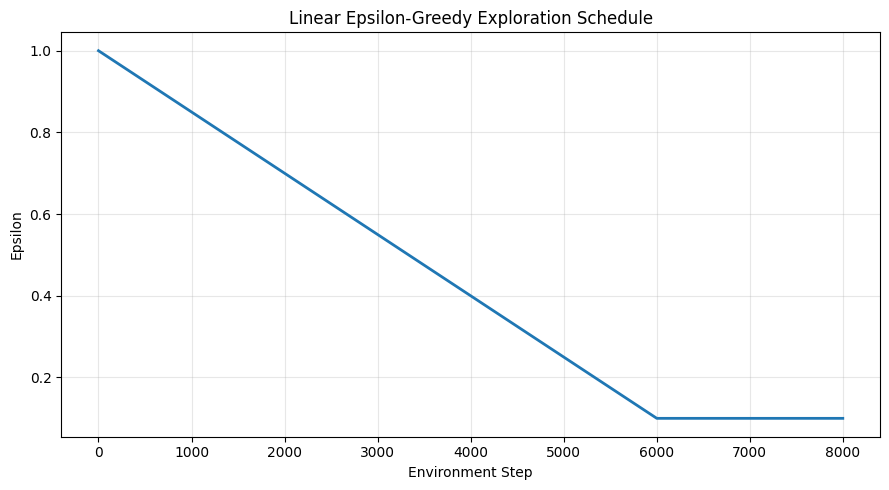


VALIDATION RESULTS
Starting epsilon test  : Passed
Minimum epsilon test   : Passed
Boundary test          : Passed
Monotonic decay test   : Passed
Plot saved to          : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\outputs\epsilon_schedule.png
File exists            : True

Epsilon schedule validation completed successfully.


In [11]:
# Implement and visualize the linear epsilon-decay schedule.

def calculate_epsilon(
    current_step: int,
    epsilon_start: float,
    epsilon_end: float,
    epsilon_decay_steps: int,
) -> float:
    """
    Calculate epsilon using linear decay.

    Parameters
    ----------
    current_step : int
        Current environment step.

    epsilon_start : float
        Exploration probability at the beginning of training.

    epsilon_end : float
        Minimum exploration probability.

    epsilon_decay_steps : int
        Number of steps over which epsilon decreases linearly.

    Returns
    -------
    float
        Epsilon value for the current step.
    """

    if current_step < 0:
        raise ValueError("Current step cannot be negative.")

    if epsilon_decay_steps <= 0:
        raise ValueError("Epsilon decay steps must be positive.")

    if not 0.0 <= epsilon_end <= epsilon_start <= 1.0:
        raise ValueError(
            "Epsilon values must satisfy "
            "0 <= epsilon_end <= epsilon_start <= 1."
        )

    decay_fraction = min(
        current_step / epsilon_decay_steps,
        1.0,
    )

    epsilon = epsilon_start + decay_fraction * (
        epsilon_end - epsilon_start
    )

    return float(epsilon)


# Calculate the schedule across the active training profile.
epsilon_steps = np.arange(
    0,
    dqn_config.total_environment_steps + 1,
)

epsilon_values = np.array(
    [
        calculate_epsilon(
            current_step=int(step),
            epsilon_start=dqn_config.epsilon_start,
            epsilon_end=dqn_config.epsilon_end,
            epsilon_decay_steps=dqn_config.epsilon_decay_steps,
        )
        for step in epsilon_steps
    ],
    dtype=np.float32,
)


# Inspect epsilon at important points during training.
inspection_steps = sorted(
    {
        0,
        dqn_config.epsilon_decay_steps // 4,
        dqn_config.epsilon_decay_steps // 2,
        (3 * dqn_config.epsilon_decay_steps) // 4,
        dqn_config.epsilon_decay_steps,
        dqn_config.total_environment_steps,
    }
)

print("=" * 70)
print("EPSILON-GREEDY EXPLORATION SCHEDULE")
print("=" * 70)
print(f"Starting epsilon       : {dqn_config.epsilon_start:.2f}")
print(f"Minimum epsilon        : {dqn_config.epsilon_end:.2f}")
print(
    f"Decay period           : "
    f"{dqn_config.epsilon_decay_steps:,} steps"
)
print(
    f"Total training steps   : "
    f"{dqn_config.total_environment_steps:,}"
)

print("\nSelected epsilon values:")

for step in inspection_steps:
    epsilon = calculate_epsilon(
        current_step=step,
        epsilon_start=dqn_config.epsilon_start,
        epsilon_end=dqn_config.epsilon_end,
        epsilon_decay_steps=dqn_config.epsilon_decay_steps,
    )

    print(f"  Step {step:>6,}: epsilon = {epsilon:.4f}")


# Plot and save the epsilon schedule.
epsilon_plot_path = outputs_directory / "epsilon_schedule.png"

plt.figure(figsize=(9, 5))
plt.plot(
    epsilon_steps,
    epsilon_values,
    linewidth=2,
)
plt.xlabel("Environment Step")
plt.ylabel("Epsilon")
plt.title("Linear Epsilon-Greedy Exploration Schedule")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    epsilon_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# Validate the schedule.
assert np.isclose(
    epsilon_values[0],
    dqn_config.epsilon_start,
)

assert np.isclose(
    calculate_epsilon(
        dqn_config.epsilon_decay_steps,
        dqn_config.epsilon_start,
        dqn_config.epsilon_end,
        dqn_config.epsilon_decay_steps,
    ),
    dqn_config.epsilon_end,
)

assert np.all(
    epsilon_values >= dqn_config.epsilon_end
)

assert np.all(
    epsilon_values <= dqn_config.epsilon_start
)

assert np.all(
    np.diff(epsilon_values) <= 1e-7
)


print("\n" + "=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)
print("Starting epsilon test  : Passed")
print("Minimum epsilon test   : Passed")
print("Boundary test          : Passed")
print("Monotonic decay test   : Passed")
print(f"Plot saved to          : {epsilon_plot_path}")
print(f"File exists            : {epsilon_plot_path.exists()}")

print("\nEpsilon schedule validation completed successfully.")

## 14. Epsilon-Greedy Action Selection

The epsilon schedule determines the probability of exploration, while the
action-selection function applies that probability at every environment step.

For each state:

1. Generate a random number between zero and one.
2. If the number is less than epsilon, select a random action.
3. Otherwise, pass the state through the DQN.
4. Select the action with the highest predicted Q-value.

During early training, most actions are selected randomly. As epsilon decreases,
the agent increasingly relies on the Q-values learned by the neural network.

The implementation also returns the decision mode so that exploration and
exploitation behavior can be tracked during training.

In [12]:
# Implement and validate epsilon-greedy action selection.

from collections import Counter
from typing import Tuple


def select_epsilon_greedy_action(
    state: np.ndarray,
    network: nn.Module,
    number_of_actions: int,
    epsilon: float,
    target_device: torch.device,
    random_generator: np.random.Generator,
) -> Tuple[int, str, float]:
    """
    Select an action using the epsilon-greedy strategy.

    Parameters
    ----------
    state : np.ndarray
        One Atari state with shape (channels, height, width).

    network : nn.Module
        DQN used to estimate action values.

    number_of_actions : int
        Number of discrete environment actions.

    epsilon : float
        Probability of selecting a random action.

    target_device : torch.device
        Device used for neural-network inference.

    random_generator : np.random.Generator
        Random-number generator used for reproducible exploration.

    Returns
    -------
    action : int
        Selected action index.

    decision_mode : str
        Either "exploration" or "exploitation".

    maximum_q_value : float
        Maximum predicted Q-value during exploitation.
        NaN is returned during random exploration because the network
        does not need to be evaluated.
    """

    if state.shape != observation_shape:
        raise ValueError(
            f"State shape {state.shape} does not match "
            f"expected shape {observation_shape}."
        )

    if not 0.0 <= epsilon <= 1.0:
        raise ValueError(
            "Epsilon must be between 0 and 1."
        )

    if number_of_actions <= 0:
        raise ValueError(
            "The number of actions must be positive."
        )

    # Exploration: select a uniformly random action.
    if random_generator.random() < epsilon:
        random_action = int(
            random_generator.integers(number_of_actions)
        )

        return random_action, "exploration", float("nan")

    # Exploitation: select the action with the highest predicted Q-value.
    state_batch = np.expand_dims(
        state,
        axis=0,
    )

    state_tensor = observations_to_tensor(
        observations=state_batch,
        target_device=target_device,
    )

    original_training_mode = network.training
    network.eval()

    with torch.no_grad():
        q_values = network(state_tensor)

    if original_training_mode:
        network.train()

    greedy_action = int(
        torch.argmax(
            q_values,
            dim=1,
        ).item()
    )

    maximum_q_value = float(
        q_values.max().item()
    )

    return greedy_action, "exploitation", maximum_q_value


# ---------------------------------------------------------
# Validate pure exploration
# ---------------------------------------------------------

action_test_generator = np.random.default_rng(
    RANDOM_SEED
)

synthetic_action_state = np.zeros(
    observation_shape,
    dtype=np.uint8,
)

exploration_results = [
    select_epsilon_greedy_action(
        state=synthetic_action_state,
        network=dqn_network,
        number_of_actions=number_of_actions,
        epsilon=1.0,
        target_device=device,
        random_generator=action_test_generator,
    )
    for _ in range(200)
]

exploration_actions = [
    result[0]
    for result in exploration_results
]

exploration_modes = [
    result[1]
    for result in exploration_results
]

exploration_counts = Counter(
    exploration_actions
)


# ---------------------------------------------------------
# Validate pure exploitation
# ---------------------------------------------------------

exploitation_results = [
    select_epsilon_greedy_action(
        state=synthetic_action_state,
        network=dqn_network,
        number_of_actions=number_of_actions,
        epsilon=0.0,
        target_device=device,
        random_generator=action_test_generator,
    )
    for _ in range(20)
]

exploitation_actions = [
    result[0]
    for result in exploitation_results
]

exploitation_modes = [
    result[1]
    for result in exploitation_results
]

exploitation_q_values = [
    result[2]
    for result in exploitation_results
]


print("=" * 70)
print("EPSILON-GREEDY ACTION-SELECTION VALIDATION")
print("=" * 70)

print("Pure exploration test:")
print(f"  Number of selections : {len(exploration_actions)}")
print(f"  Action counts        : {dict(sorted(exploration_counts.items()))}")
print(
    f"  Unique actions       : "
    f"{sorted(set(exploration_actions))}"
)
print(
    f"  All exploration      : "
    f"{all(mode == 'exploration' for mode in exploration_modes)}"
)

print("\nPure exploitation test:")
print(f"  Number of selections : {len(exploitation_actions)}")
print(
    f"  Selected actions     : "
    f"{sorted(set(exploitation_actions))}"
)
print(
    f"  All exploitation     : "
    f"{all(mode == 'exploitation' for mode in exploitation_modes)}"
)
print(
    f"  Greedy action stable : "
    f"{len(set(exploitation_actions)) == 1}"
)
print(
    f"  Maximum Q-value      : "
    f"{exploitation_q_values[0]:.6f}"
)


# ---------------------------------------------------------
# Validate error handling
# ---------------------------------------------------------

try:
    select_epsilon_greedy_action(
        state=synthetic_action_state,
        network=dqn_network,
        number_of_actions=number_of_actions,
        epsilon=1.5,
        target_device=device,
        random_generator=action_test_generator,
    )
except ValueError as error:
    epsilon_error_message = str(error)
else:
    raise AssertionError(
        "An invalid epsilon value should raise an error."
    )


# ---------------------------------------------------------
# Assertions
# ---------------------------------------------------------

assert all(
    mode == "exploration"
    for mode in exploration_modes
)

assert len(
    set(exploration_actions)
) > 1

assert all(
    mode == "exploitation"
    for mode in exploitation_modes
)

assert len(
    set(exploitation_actions)
) == 1

assert all(
    np.isfinite(q_value)
    for q_value in exploitation_q_values
)

assert all(
    0 <= action < number_of_actions
    for action in exploration_actions + exploitation_actions
)


print("\n" + "=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)
print("Pure exploration test   : Passed")
print("Pure exploitation test  : Passed")
print("Action-boundary test    : Passed")
print("Stable greedy test      : Passed")
print("Finite Q-value test     : Passed")
print("Invalid epsilon test    : Passed")
print(f"Expected error message  : {epsilon_error_message}")

print("\nEpsilon-greedy action selection validated successfully.")

EPSILON-GREEDY ACTION-SELECTION VALIDATION
Pure exploration test:
  Number of selections : 200
  Action counts        : {0: 60, 1: 49, 2: 35, 3: 56}
  Unique actions       : [0, 1, 2, 3]
  All exploration      : True

Pure exploitation test:
  Number of selections : 20
  Selected actions     : [0]
  All exploitation     : True
  Greedy action stable : True
  Maximum Q-value      : 0.000000

VALIDATION RESULTS
Pure exploration test   : Passed
Pure exploitation test  : Passed
Action-boundary test    : Passed
Stable greedy test      : Passed
Finite Q-value test     : Passed
Invalid epsilon test    : Passed
Expected error message  : Epsilon must be between 0 and 1.

Epsilon-greedy action selection validated successfully.


## 15. Online Network, Target Network, and Optimizer

DQN uses two neural networks with the same architecture.

The **online network** is updated through gradient descent and is used for
epsilon-greedy action selection. The **target network** provides relatively
stable Q-value targets during training.

At fixed intervals, the parameters of the online network are copied to the
target network. Between these synchronization points, the target network
remains unchanged.

The Adam optimizer updates only the online network. The training objective uses
Huber loss, implemented as `SmoothL1Loss`, because it is less sensitive to large
temporal-difference errors than ordinary mean squared error.

In [13]:
# Create the online and target DQN networks, optimizer, and loss function.

import copy

import torch.optim as optim


def synchronize_target_network(
    online_network: nn.Module,
    target_network: nn.Module,
) -> None:
    """
    Copy all parameters and buffers from the online network
    to the target network.
    """
    target_network.load_state_dict(
        online_network.state_dict()
    )


# ---------------------------------------------------------
# Create the two DQN networks
# ---------------------------------------------------------

online_network = AtariDQN(
    observation_shape=observation_shape,
    number_of_actions=number_of_actions,
).to(device)

target_network = AtariDQN(
    observation_shape=observation_shape,
    number_of_actions=number_of_actions,
).to(device)


# Make the initial target network identical to the online network.
synchronize_target_network(
    online_network=online_network,
    target_network=target_network,
)


# The target network is used only for inference.
target_network.eval()

for parameter in target_network.parameters():
    parameter.requires_grad = False


# ---------------------------------------------------------
# Configure optimization
# ---------------------------------------------------------

optimizer = optim.Adam(
    online_network.parameters(),
    lr=dqn_config.learning_rate,
)

loss_function = nn.SmoothL1Loss()


# ---------------------------------------------------------
# Validate initial synchronization
# ---------------------------------------------------------

parameters_initially_equal = all(
    torch.equal(
        online_parameter,
        target_parameter,
    )
    for online_parameter, target_parameter in zip(
        online_network.parameters(),
        target_network.parameters(),
    )
)


# Compare outputs for the same normalized sample observations.
online_network.eval()

with torch.no_grad():
    online_test_output = online_network(
        test_state_tensor
    )

    target_test_output = target_network(
        test_state_tensor
    )

outputs_initially_equal = torch.allclose(
    online_test_output,
    target_test_output,
    atol=1e-7,
)


# Return the online network to training mode.
online_network.train()


# ---------------------------------------------------------
# Validate that the target network is frozen
# ---------------------------------------------------------

target_parameters_frozen = all(
    not parameter.requires_grad
    for parameter in target_network.parameters()
)

optimizer_parameter_count = sum(
    parameter.numel()
    for parameter_group in optimizer.param_groups
    for parameter in parameter_group["params"]
)

online_trainable_parameter_count = sum(
    parameter.numel()
    for parameter in online_network.parameters()
    if parameter.requires_grad
)


print("=" * 70)
print("DQN TRAINING COMPONENTS")
print("=" * 70)
print(f"Online network device     : {next(online_network.parameters()).device}")
print(f"Target network device     : {next(target_network.parameters()).device}")
print(f"Online network mode       : {'training' if online_network.training else 'evaluation'}")
print(f"Target network mode       : {'training' if target_network.training else 'evaluation'}")
print(f"Optimizer                 : {optimizer.__class__.__name__}")
print(f"Learning rate             : {optimizer.param_groups[0]['lr']}")
print(f"Loss function             : {loss_function.__class__.__name__}")
print(f"Target update frequency   : {dqn_config.target_update_frequency:,} steps")

print("\n" + "=" * 70)
print("NETWORK VALIDATION")
print("=" * 70)
print(f"Parameters synchronized   : {parameters_initially_equal}")
print(f"Outputs synchronized      : {outputs_initially_equal}")
print(f"Target parameters frozen  : {target_parameters_frozen}")
print(f"Online trainable params   : {online_trainable_parameter_count:,}")
print(f"Optimizer parameter count : {optimizer_parameter_count:,}")


# ---------------------------------------------------------
# Assertions
# ---------------------------------------------------------

assert parameters_initially_equal
assert outputs_initially_equal
assert target_parameters_frozen

assert (
    optimizer_parameter_count
    == online_trainable_parameter_count
)

assert optimizer.param_groups[0]["lr"] == (
    dqn_config.learning_rate
)


print("\n" + "=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)
print("Initial synchronization : Passed")
print("Output equality test    : Passed")
print("Frozen target test      : Passed")
print("Optimizer scope test    : Passed")
print("Learning-rate test      : Passed")

print("\nDQN training components created successfully.")

DQN TRAINING COMPONENTS
Online network device     : cpu
Target network device     : cpu
Online network mode       : training
Target network mode       : evaluation
Optimizer                 : Adam
Learning rate             : 0.0001
Loss function             : SmoothL1Loss
Target update frequency   : 1,000 steps

NETWORK VALIDATION
Parameters synchronized   : True
Outputs synchronized      : True
Target parameters frozen  : True
Online trainable params   : 1,686,180
Optimizer parameter count : 1,686,180

VALIDATION RESULTS
Initial synchronization : Passed
Output equality test    : Passed
Frozen target test      : Passed
Optimizer scope test    : Passed
Learning-rate test      : Passed

DQN training components created successfully.


## 16. DQN Bellman Learning Update

The DQN learning update trains the online network using randomly sampled
transitions from experience replay.

For each sampled transition, the online network predicts Q-values for every
possible action. Only the Q-value corresponding to the action actually selected
by the agent is used in the loss calculation.

The target network calculates the maximum predicted Q-value for the next state.
The Bellman target is:

\[
y_t =
r_{t+1}
+
\gamma(1-d_t)
\max_{a'} Q_{\text{target}}(s_{t+1}, a')
\]

where \(d_t\) indicates whether the episode ended after the transition.

The target calculation is performed without gradient tracking. Therefore, only
the online network is updated by backpropagation. Gradient clipping is applied
to reduce the risk of unstable parameter updates.

In [14]:
# Implement and validate one DQN optimization update.

from dataclasses import dataclass


@dataclass
class DQNUpdateMetrics:
    """
    Metrics produced by one DQN optimization step.
    """

    loss: float
    mean_predicted_q_value: float
    mean_target_q_value: float
    mean_absolute_td_error: float
    gradient_norm: float


def perform_dqn_update(
    replay_memory: ReplayBuffer,
    online_network: nn.Module,
    target_network: nn.Module,
    optimizer: torch.optim.Optimizer,
    loss_function: nn.Module,
    batch_size: int,
    discount_factor: float,
    gradient_clip_norm: float,
    target_device: torch.device,
) -> DQNUpdateMetrics:
    """
    Sample one minibatch and perform one DQN optimization update.

    Parameters
    ----------
    replay_memory : ReplayBuffer
        Replay buffer containing previously collected transitions.

    online_network : nn.Module
        Network updated through gradient descent.

    target_network : nn.Module
        Frozen network used to calculate Bellman targets.

    optimizer : torch.optim.Optimizer
        Optimizer responsible for updating the online network.

    loss_function : nn.Module
        Loss function comparing predicted and target Q-values.

    batch_size : int
        Number of transitions sampled for the update.

    discount_factor : float
        Gamma value used to discount future rewards.

    gradient_clip_norm : float
        Maximum allowed gradient norm.

    target_device : torch.device
        CPU or GPU device used for tensor operations.

    Returns
    -------
    DQNUpdateMetrics
        Loss, Q-value, temporal-difference error, and gradient metrics.
    """

    if len(replay_memory) < batch_size:
        raise ValueError(
            f"The replay buffer contains {len(replay_memory)} "
            f"transitions, but a batch of {batch_size} is required."
        )

    if not 0.0 <= discount_factor <= 1.0:
        raise ValueError(
            "The discount factor must be between 0 and 1."
        )

    if gradient_clip_norm <= 0:
        raise ValueError(
            "The gradient clipping norm must be positive."
        )

    # ---------------------------------------------------------
    # Sample a random minibatch
    # ---------------------------------------------------------

    replay_batch = replay_memory.sample(batch_size)

    states = observations_to_tensor(
        replay_batch.states,
        target_device,
    )

    next_states = observations_to_tensor(
        replay_batch.next_states,
        target_device,
    )

    actions = torch.as_tensor(
        replay_batch.actions,
        dtype=torch.int64,
        device=target_device,
    )

    rewards = torch.as_tensor(
        replay_batch.rewards,
        dtype=torch.float32,
        device=target_device,
    )

    dones = torch.as_tensor(
        replay_batch.dones,
        dtype=torch.float32,
        device=target_device,
    )

    # ---------------------------------------------------------
    # Calculate online-network predictions
    # ---------------------------------------------------------

    online_network.train()

    all_predicted_q_values = online_network(states)

    # Select Q(s, a) for the actions stored in the transitions.
    predicted_q_values = all_predicted_q_values.gather(
        dim=1,
        index=actions.unsqueeze(1),
    ).squeeze(1)

    # ---------------------------------------------------------
    # Calculate fixed Bellman targets
    # ---------------------------------------------------------

    target_network.eval()

    with torch.no_grad():
        next_q_values = target_network(next_states)

        maximum_next_q_values = next_q_values.max(
            dim=1
        ).values

        bellman_targets = rewards + (
            discount_factor
            * (1.0 - dones)
            * maximum_next_q_values
        )

    # ---------------------------------------------------------
    # Calculate the temporal-difference loss
    # ---------------------------------------------------------

    loss = loss_function(
        predicted_q_values,
        bellman_targets,
    )

    temporal_difference_errors = (
        bellman_targets - predicted_q_values
    )

    # ---------------------------------------------------------
    # Update only the online network
    # ---------------------------------------------------------

    optimizer.zero_grad(set_to_none=True)

    loss.backward()

    gradient_norm = torch.nn.utils.clip_grad_norm_(
        online_network.parameters(),
        max_norm=gradient_clip_norm,
    )

    optimizer.step()

    return DQNUpdateMetrics(
        loss=float(loss.item()),
        mean_predicted_q_value=float(
            predicted_q_values.detach().mean().item()
        ),
        mean_target_q_value=float(
            bellman_targets.detach().mean().item()
        ),
        mean_absolute_td_error=float(
            temporal_difference_errors.detach().abs().mean().item()
        ),
        gradient_norm=float(gradient_norm),
    )


# ---------------------------------------------------------
# Create controlled validation transitions
# ---------------------------------------------------------

validation_generator = np.random.default_rng(
    RANDOM_SEED
)

validation_replay_buffer = ReplayBuffer(
    capacity=64,
    observation_shape=observation_shape,
    seed=RANDOM_SEED,
)

for transition_index in range(64):
    validation_state = validation_generator.integers(
        low=0,
        high=256,
        size=observation_shape,
        dtype=np.uint8,
    )

    validation_next_state = validation_generator.integers(
        low=0,
        high=256,
        size=observation_shape,
        dtype=np.uint8,
    )

    validation_action = (
        transition_index % number_of_actions
    )

    validation_reward = float(
        (transition_index % 5) - 2
    )

    validation_done = (
        transition_index % 11 == 0
    )

    validation_replay_buffer.add(
        state=validation_state,
        action=validation_action,
        reward=validation_reward,
        next_state=validation_next_state,
        done=validation_done,
    )


# ---------------------------------------------------------
# Use separate networks so the main training networks remain unchanged
# ---------------------------------------------------------

validation_online_network = copy.deepcopy(
    online_network
).to(device)

validation_target_network = copy.deepcopy(
    target_network
).to(device)

validation_target_network.eval()

for parameter in validation_target_network.parameters():
    parameter.requires_grad = False


validation_optimizer = optim.Adam(
    validation_online_network.parameters(),
    lr=dqn_config.learning_rate,
)


online_parameters_before = [
    parameter.detach().clone()
    for parameter in validation_online_network.parameters()
]

target_parameters_before = [
    parameter.detach().clone()
    for parameter in validation_target_network.parameters()
]


# ---------------------------------------------------------
# Perform one learning update
# ---------------------------------------------------------

validation_metrics = perform_dqn_update(
    replay_memory=validation_replay_buffer,
    online_network=validation_online_network,
    target_network=validation_target_network,
    optimizer=validation_optimizer,
    loss_function=loss_function,
    batch_size=dqn_config.batch_size,
    discount_factor=dqn_config.discount_factor,
    gradient_clip_norm=dqn_config.gradient_clip_norm,
    target_device=device,
)


online_parameters_changed = any(
    not torch.equal(before, after)
    for before, after in zip(
        online_parameters_before,
        validation_online_network.parameters(),
    )
)

target_parameters_unchanged = all(
    torch.equal(before, after)
    for before, after in zip(
        target_parameters_before,
        validation_target_network.parameters(),
    )
)

target_gradients_absent = all(
    parameter.grad is None
    for parameter in validation_target_network.parameters()
)


print("=" * 70)
print("DQN BELLMAN UPDATE VALIDATION")
print("=" * 70)
print(
    f"Validation buffer size   : "
    f"{len(validation_replay_buffer)}"
)
print(
    f"Training batch size      : "
    f"{dqn_config.batch_size}"
)
print(
    f"Discount factor          : "
    f"{dqn_config.discount_factor}"
)
print(
    f"Loss                     : "
    f"{validation_metrics.loss:.6f}"
)
print(
    f"Mean predicted Q-value   : "
    f"{validation_metrics.mean_predicted_q_value:.6f}"
)
print(
    f"Mean target Q-value      : "
    f"{validation_metrics.mean_target_q_value:.6f}"
)
print(
    f"Mean absolute TD error   : "
    f"{validation_metrics.mean_absolute_td_error:.6f}"
)
print(
    f"Gradient norm            : "
    f"{validation_metrics.gradient_norm:.6f}"
)

print("\n" + "=" * 70)
print("PARAMETER VALIDATION")
print("=" * 70)
print(
    f"Online parameters changed : "
    f"{online_parameters_changed}"
)
print(
    f"Target parameters unchanged: "
    f"{target_parameters_unchanged}"
)
print(
    f"Target gradients absent    : "
    f"{target_gradients_absent}"
)


# ---------------------------------------------------------
# Assertions
# ---------------------------------------------------------

assert np.isfinite(validation_metrics.loss)
assert np.isfinite(
    validation_metrics.mean_predicted_q_value
)
assert np.isfinite(
    validation_metrics.mean_target_q_value
)
assert np.isfinite(
    validation_metrics.mean_absolute_td_error
)
assert np.isfinite(
    validation_metrics.gradient_norm
)

assert validation_metrics.loss >= 0.0
assert validation_metrics.mean_absolute_td_error >= 0.0
assert online_parameters_changed
assert target_parameters_unchanged
assert target_gradients_absent


print("\n" + "=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)
print("Finite loss test          : Passed")
print("Finite Q-value test       : Passed")
print("Finite TD-error test      : Passed")
print("Online update test        : Passed")
print("Frozen target test        : Passed")
print("Target gradient test      : Passed")

print("\nDQN Bellman learning update validated successfully.")

DQN BELLMAN UPDATE VALIDATION
Validation buffer size   : 64
Training batch size      : 32
Discount factor          : 0.99
Loss                     : 1.050768
Mean predicted Q-value   : 0.050378
Mean target Q-value      : 1.007893
Mean absolute TD error   : 1.486869
Gradient norm            : 10.016948

PARAMETER VALIDATION
Online parameters changed : True
Target parameters unchanged: True
Target gradients absent    : True

VALIDATION RESULTS
Finite loss test          : Passed
Finite Q-value test       : Passed
Finite TD-error test      : Passed
Online update test        : Passed
Frozen target test        : Passed
Target gradient test      : Passed

DQN Bellman learning update validated successfully.


## 17. End-to-End DQN Smoke Test

Before launching the complete training run, a short smoke test verifies that all
DQN components work together correctly.

During this test, the agent:

- interacts with the preprocessed Breakout environment,
- selects actions using epsilon-greedy exploration,
- stores transitions in experience replay,
- begins learning after the replay warm-up period,
- performs Bellman optimization updates,
- synchronizes the target network,
- records episode rewards, losses, Q-values, and exploration decisions.

The smoke test is intended to identify integration problems. Its limited number
of environment steps is not sufficient to demonstrate strong Atari learning.

In [15]:
# Run a short end-to-end DQN smoke test.

import time


# ---------------------------------------------------------
# Smoke-test configuration
# ---------------------------------------------------------

SMOKE_TEST_STEPS = max(
    dqn_config.learning_starts + 250,
    dqn_config.target_update_frequency + 250,
)

smoke_replay_capacity = max(
    SMOKE_TEST_STEPS,
    dqn_config.batch_size,
)


# ---------------------------------------------------------
# Create isolated smoke-test components
# ---------------------------------------------------------

smoke_environment = create_atari_environment(
    render_mode=None,
    seed=RANDOM_SEED,
)

smoke_online_network = AtariDQN(
    observation_shape=observation_shape,
    number_of_actions=number_of_actions,
).to(device)

smoke_target_network = AtariDQN(
    observation_shape=observation_shape,
    number_of_actions=number_of_actions,
).to(device)

synchronize_target_network(
    online_network=smoke_online_network,
    target_network=smoke_target_network,
)

smoke_target_network.eval()

for parameter in smoke_target_network.parameters():
    parameter.requires_grad = False


smoke_optimizer = optim.Adam(
    smoke_online_network.parameters(),
    lr=dqn_config.learning_rate,
)

smoke_replay_buffer = ReplayBuffer(
    capacity=smoke_replay_capacity,
    observation_shape=observation_shape,
    seed=RANDOM_SEED,
)

smoke_random_generator = np.random.default_rng(
    RANDOM_SEED
)


# ---------------------------------------------------------
# Metrics collected during the smoke test
# ---------------------------------------------------------

smoke_episode_rewards = []
smoke_episode_lengths = []
smoke_losses = []
smoke_predicted_q_values = []
smoke_target_q_values = []
smoke_td_errors = []
smoke_gradient_norms = []
smoke_exploitation_q_values = []

smoke_exploration_count = 0
smoke_exploitation_count = 0
smoke_update_count = 0
smoke_target_sync_count = 0
smoke_synchronization_checks = []


# ---------------------------------------------------------
# Reset the environment
# ---------------------------------------------------------

smoke_state, smoke_reset_info = smoke_environment.reset(
    seed=RANDOM_SEED
)

current_episode_reward = 0.0
current_episode_length = 0

smoke_start_time = time.perf_counter()


# ---------------------------------------------------------
# Environment interaction and learning loop
# ---------------------------------------------------------

try:
    for environment_step in range(
        1,
        SMOKE_TEST_STEPS + 1,
    ):
        epsilon = calculate_epsilon(
            current_step=environment_step - 1,
            epsilon_start=dqn_config.epsilon_start,
            epsilon_end=dqn_config.epsilon_end,
            epsilon_decay_steps=dqn_config.epsilon_decay_steps,
        )

        (
            selected_action,
            decision_mode,
            selected_maximum_q_value,
        ) = select_epsilon_greedy_action(
            state=smoke_state,
            network=smoke_online_network,
            number_of_actions=number_of_actions,
            epsilon=epsilon,
            target_device=device,
            random_generator=smoke_random_generator,
        )

        if decision_mode == "exploration":
            smoke_exploration_count += 1
        else:
            smoke_exploitation_count += 1
            smoke_exploitation_q_values.append(
                selected_maximum_q_value
            )

        (
            smoke_next_state,
            reward,
            terminated,
            truncated,
            step_information,
        ) = smoke_environment.step(selected_action)

        episode_finished = bool(
            terminated or truncated
        )

        # Termination prevents Bellman bootstrapping.
        # A time-limit truncation does not necessarily represent
        # a terminal MDP state.
        terminal_for_learning = bool(terminated)

        smoke_replay_buffer.add(
            state=np.asarray(
                smoke_state,
                dtype=np.uint8,
            ),
            action=selected_action,
            reward=float(reward),
            next_state=np.asarray(
                smoke_next_state,
                dtype=np.uint8,
            ),
            done=terminal_for_learning,
        )

        current_episode_reward += float(reward)
        current_episode_length += 1

        smoke_state = smoke_next_state

        # -------------------------------------------------
        # Perform a DQN optimization update
        # -------------------------------------------------

        learning_ready = (
            len(smoke_replay_buffer)
            >= dqn_config.learning_starts
        )

        scheduled_training_step = (
            environment_step
            % dqn_config.train_frequency
            == 0
        )

        if learning_ready and scheduled_training_step:
            update_metrics = perform_dqn_update(
                replay_memory=smoke_replay_buffer,
                online_network=smoke_online_network,
                target_network=smoke_target_network,
                optimizer=smoke_optimizer,
                loss_function=loss_function,
                batch_size=dqn_config.batch_size,
                discount_factor=dqn_config.discount_factor,
                gradient_clip_norm=dqn_config.gradient_clip_norm,
                target_device=device,
            )

            smoke_losses.append(
                update_metrics.loss
            )

            smoke_predicted_q_values.append(
                update_metrics.mean_predicted_q_value
            )

            smoke_target_q_values.append(
                update_metrics.mean_target_q_value
            )

            smoke_td_errors.append(
                update_metrics.mean_absolute_td_error
            )

            smoke_gradient_norms.append(
                update_metrics.gradient_norm
            )

            smoke_update_count += 1

        # -------------------------------------------------
        # Periodically synchronize the target network
        # -------------------------------------------------

        if (
            environment_step
            % dqn_config.target_update_frequency
            == 0
        ):
            synchronize_target_network(
                online_network=smoke_online_network,
                target_network=smoke_target_network,
            )

            synchronization_successful = all(
                torch.equal(
                    online_parameter,
                    target_parameter,
                )
                for online_parameter, target_parameter in zip(
                    smoke_online_network.parameters(),
                    smoke_target_network.parameters(),
                )
            )

            smoke_synchronization_checks.append(
                synchronization_successful
            )

            smoke_target_sync_count += 1

        # -------------------------------------------------
        # Reset after a completed episode
        # -------------------------------------------------

        if episode_finished:
            smoke_episode_rewards.append(
                current_episode_reward
            )

            smoke_episode_lengths.append(
                current_episode_length
            )

            smoke_state, smoke_reset_info = (
                smoke_environment.reset()
            )

            current_episode_reward = 0.0
            current_episode_length = 0

        # -------------------------------------------------
        # Display limited progress information
        # -------------------------------------------------

        if (
            environment_step % 250 == 0
            or environment_step == SMOKE_TEST_STEPS
        ):
            if smoke_losses:
                recent_mean_loss = float(
                    np.mean(smoke_losses[-25:])
                )
                loss_display = f"{recent_mean_loss:.6f}"
            else:
                loss_display = "Not started"

            print(
                f"Step {environment_step:>5,}/"
                f"{SMOKE_TEST_STEPS:,} | "
                f"Buffer {len(smoke_replay_buffer):>5,} | "
                f"Epsilon {epsilon:.4f} | "
                f"Updates {smoke_update_count:>3} | "
                f"Recent loss {loss_display}"
            )

finally:
    smoke_environment.close()


smoke_elapsed_seconds = (
    time.perf_counter() - smoke_start_time
)


# ---------------------------------------------------------
# Create a reusable smoke-test summary
# ---------------------------------------------------------

smoke_test_summary = {
    "environment_steps": SMOKE_TEST_STEPS,
    "replay_buffer_size": len(smoke_replay_buffer),
    "completed_episodes": len(smoke_episode_rewards),
    "optimization_updates": smoke_update_count,
    "target_synchronizations": smoke_target_sync_count,
    "exploration_actions": smoke_exploration_count,
    "exploitation_actions": smoke_exploitation_count,
    "mean_loss": (
        float(np.mean(smoke_losses))
        if smoke_losses
        else float("nan")
    ),
    "mean_predicted_q_value": (
        float(np.mean(smoke_predicted_q_values))
        if smoke_predicted_q_values
        else float("nan")
    ),
    "mean_target_q_value": (
        float(np.mean(smoke_target_q_values))
        if smoke_target_q_values
        else float("nan")
    ),
    "mean_absolute_td_error": (
        float(np.mean(smoke_td_errors))
        if smoke_td_errors
        else float("nan")
    ),
    "elapsed_seconds": smoke_elapsed_seconds,
}


print("\n" + "=" * 72)
print("END-TO-END DQN SMOKE-TEST SUMMARY")
print("=" * 72)
print(
    f"Environment steps        : "
    f"{smoke_test_summary['environment_steps']:,}"
)
print(
    f"Replay-buffer size       : "
    f"{smoke_test_summary['replay_buffer_size']:,}"
)
print(
    f"Completed episodes       : "
    f"{smoke_test_summary['completed_episodes']}"
)
print(
    f"Optimization updates     : "
    f"{smoke_test_summary['optimization_updates']}"
)
print(
    f"Target synchronizations : "
    f"{smoke_test_summary['target_synchronizations']}"
)
print(
    f"Exploration actions      : "
    f"{smoke_test_summary['exploration_actions']:,}"
)
print(
    f"Exploitation actions     : "
    f"{smoke_test_summary['exploitation_actions']:,}"
)
print(
    f"Mean loss                : "
    f"{smoke_test_summary['mean_loss']:.6f}"
)
print(
    f"Mean predicted Q-value   : "
    f"{smoke_test_summary['mean_predicted_q_value']:.6f}"
)
print(
    f"Mean target Q-value      : "
    f"{smoke_test_summary['mean_target_q_value']:.6f}"
)
print(
    f"Mean absolute TD error   : "
    f"{smoke_test_summary['mean_absolute_td_error']:.6f}"
)
print(
    f"Elapsed time             : "
    f"{smoke_test_summary['elapsed_seconds']:.2f} seconds"
)


# ---------------------------------------------------------
# Validate the complete integration
# ---------------------------------------------------------

expected_buffer_size = min(
    SMOKE_TEST_STEPS,
    smoke_replay_capacity,
)

assert len(smoke_replay_buffer) == expected_buffer_size
assert smoke_update_count > 0
assert smoke_target_sync_count > 0
assert all(smoke_synchronization_checks)

assert (
    smoke_exploration_count
    + smoke_exploitation_count
    == SMOKE_TEST_STEPS
)

assert np.isfinite(smoke_losses).all()
assert np.isfinite(smoke_predicted_q_values).all()
assert np.isfinite(smoke_target_q_values).all()
assert np.isfinite(smoke_td_errors).all()
assert np.isfinite(smoke_gradient_norms).all()


print("\n" + "=" * 72)
print("VALIDATION RESULTS")
print("=" * 72)
print("Environment interaction     : Passed")
print("Replay insertion            : Passed")
print("Epsilon-greedy selection    : Passed")
print("Bellman optimization        : Passed")
print("Target synchronization      : Passed")
print("Learning-metric collection  : Passed")
print("Finite numerical values     : Passed")

print("\nEnd-to-end DQN smoke test completed successfully.")

Step   250/1,250 | Buffer   250 | Epsilon 0.9627 | Updates   0 | Recent loss Not started
Step   500/1,250 | Buffer   500 | Epsilon 0.9252 | Updates   0 | Recent loss Not started
Step   750/1,250 | Buffer   750 | Epsilon 0.8877 | Updates   0 | Recent loss Not started
Step 1,000/1,250 | Buffer 1,000 | Epsilon 0.8501 | Updates   1 | Recent loss 0.388094
Step 1,250/1,250 | Buffer 1,250 | Epsilon 0.8126 | Updates  63 | Recent loss 0.010323

END-TO-END DQN SMOKE-TEST SUMMARY
Environment steps        : 1,250
Replay-buffer size       : 1,250
Completed episodes       : 5
Optimization updates     : 63
Target synchronizations : 1
Exploration actions      : 1,122
Exploitation actions     : 128
Mean loss                : 0.030558
Mean predicted Q-value   : 0.834370
Mean target Q-value      : 0.847289
Mean absolute TD error   : 0.126741
Elapsed time             : 5.82 seconds

VALIDATION RESULTS
Environment interaction     : Passed
Replay insertion            : Passed
Epsilon-greedy selection    : P

## 18. Training History and Model Checkpointing

Longer DQN training runs must preserve both the learned model and the metrics
needed for performance evaluation.

The training history records:

- episode number,
- episode reward,
- episode length,
- environment step,
- epsilon,
- loss,
- predicted Q-values,
- target Q-values,
- temporal-difference error,
- gradient norm.

Model checkpoints store the online network, target network, optimizer, current
training progress, hyperparameters, and summary metrics.

These saved files allow training to be inspected, evaluated, or resumed in
either the local environment or Google Colab.

In [16]:
# Define reusable structures and utilities for training history and checkpoints.

from dataclasses import dataclass, field
from datetime import datetime
from typing import Any

import pandas as pd


@dataclass
class TrainingHistory:
    """
    Store episode-level and optimization-level DQN metrics.
    """

    # Episode-level metrics
    episode_numbers: list = field(default_factory=list)
    episode_steps: list = field(default_factory=list)
    episode_rewards: list = field(default_factory=list)
    episode_lengths: list = field(default_factory=list)
    episode_epsilons: list = field(default_factory=list)

    # Optimization-level metrics
    update_steps: list = field(default_factory=list)
    losses: list = field(default_factory=list)
    predicted_q_values: list = field(default_factory=list)
    target_q_values: list = field(default_factory=list)
    td_errors: list = field(default_factory=list)
    gradient_norms: list = field(default_factory=list)

    # Evaluation metrics will be added later
    evaluation_steps: list = field(default_factory=list)
    evaluation_mean_rewards: list = field(default_factory=list)
    evaluation_std_rewards: list = field(default_factory=list)


def create_episode_metrics_dataframe(
    history: TrainingHistory,
) -> pd.DataFrame:
    """
    Convert episode-level training history into a DataFrame.
    """

    return pd.DataFrame(
        {
            "episode": history.episode_numbers,
            "environment_step": history.episode_steps,
            "episode_reward": history.episode_rewards,
            "episode_length": history.episode_lengths,
            "epsilon": history.episode_epsilons,
        }
    )


def create_update_metrics_dataframe(
    history: TrainingHistory,
) -> pd.DataFrame:
    """
    Convert optimization-level training history into a DataFrame.
    """

    return pd.DataFrame(
        {
            "environment_step": history.update_steps,
            "loss": history.losses,
            "mean_predicted_q_value": history.predicted_q_values,
            "mean_target_q_value": history.target_q_values,
            "mean_absolute_td_error": history.td_errors,
            "gradient_norm": history.gradient_norms,
        }
    )


def save_training_metrics(
    history: TrainingHistory,
    output_directory: Path,
    file_prefix: str = "dqn_training",
) -> dict:
    """
    Save episode-level and update-level metrics as CSV files.
    """

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    episode_metrics_path = (
        output_directory
        / f"{file_prefix}_episode_metrics.csv"
    )

    update_metrics_path = (
        output_directory
        / f"{file_prefix}_update_metrics.csv"
    )

    episode_dataframe = create_episode_metrics_dataframe(
        history
    )

    update_dataframe = create_update_metrics_dataframe(
        history
    )

    episode_dataframe.to_csv(
        episode_metrics_path,
        index=False,
    )

    update_dataframe.to_csv(
        update_metrics_path,
        index=False,
    )

    return {
        "episode_metrics_path": episode_metrics_path,
        "update_metrics_path": update_metrics_path,
        "episode_rows": len(episode_dataframe),
        "update_rows": len(update_dataframe),
    }


def save_dqn_checkpoint(
    checkpoint_path: Path,
    online_network: nn.Module,
    target_network: nn.Module,
    optimizer: torch.optim.Optimizer,
    environment_step: int,
    episode_number: int,
    epsilon: float,
    configuration: DQNConfig,
    history: TrainingHistory,
    additional_information: dict | None = None,
) -> None:
    """
    Save all important DQN training state to one checkpoint file.
    """

    checkpoint_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint_data = {
        "environment_step": int(environment_step),
        "episode_number": int(episode_number),
        "epsilon": float(epsilon),
        "environment_id": ENVIRONMENT_ID,
        "observation_shape": observation_shape,
        "number_of_actions": number_of_actions,
        "runtime_environment": runtime_environment,
        "training_profile": active_profile,
        "configuration": asdict(configuration),
        "online_network_state_dict": (
            online_network.state_dict()
        ),
        "target_network_state_dict": (
            target_network.state_dict()
        ),
        "optimizer_state_dict": optimizer.state_dict(),
        "training_history": history,
        "saved_at": datetime.now().isoformat(
            timespec="seconds"
        ),
        "additional_information": (
            additional_information or {}
        ),
    }

    torch.save(
        checkpoint_data,
        checkpoint_path,
    )


def load_dqn_checkpoint(
    checkpoint_path: Path,
    online_network: nn.Module,
    target_network: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    target_device: torch.device,
) -> dict:
    """
    Load a saved checkpoint into the supplied networks and optimizer.
    """

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}"
        )

    checkpoint_data = torch.load(
        checkpoint_path,
        map_location=target_device,
        weights_only=False,
    )

    online_network.load_state_dict(
        checkpoint_data["online_network_state_dict"]
    )

    target_network.load_state_dict(
        checkpoint_data["target_network_state_dict"]
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint_data["optimizer_state_dict"]
        )

    online_network.to(target_device)
    target_network.to(target_device)

    return checkpoint_data


# ---------------------------------------------------------
# Validate the utilities with a small temporary checkpoint
# ---------------------------------------------------------

checkpoint_validation_history = TrainingHistory()

checkpoint_validation_history.episode_numbers.append(1)
checkpoint_validation_history.episode_steps.append(100)
checkpoint_validation_history.episode_rewards.append(2.0)
checkpoint_validation_history.episode_lengths.append(100)
checkpoint_validation_history.episode_epsilons.append(0.90)

checkpoint_validation_history.update_steps.append(100)
checkpoint_validation_history.losses.append(0.25)
checkpoint_validation_history.predicted_q_values.append(0.40)
checkpoint_validation_history.target_q_values.append(0.55)
checkpoint_validation_history.td_errors.append(0.15)
checkpoint_validation_history.gradient_norms.append(1.20)


temporary_checkpoint_path = (
    checkpoints_directory
    / "checkpoint_utility_validation.pt"
)

save_dqn_checkpoint(
    checkpoint_path=temporary_checkpoint_path,
    online_network=online_network,
    target_network=target_network,
    optimizer=optimizer,
    environment_step=100,
    episode_number=1,
    epsilon=0.90,
    configuration=dqn_config,
    history=checkpoint_validation_history,
    additional_information={
        "purpose": "checkpoint utility validation"
    },
)


loaded_validation_checkpoint = torch.load(
    temporary_checkpoint_path,
    map_location=device,
    weights_only=False,
)


required_checkpoint_keys = {
    "environment_step",
    "episode_number",
    "epsilon",
    "environment_id",
    "configuration",
    "online_network_state_dict",
    "target_network_state_dict",
    "optimizer_state_dict",
    "training_history",
    "saved_at",
}


assert temporary_checkpoint_path.exists()

assert required_checkpoint_keys.issubset(
    loaded_validation_checkpoint.keys()
)

assert (
    loaded_validation_checkpoint["environment_step"]
    == 100
)

assert (
    loaded_validation_checkpoint["episode_number"]
    == 1
)

assert np.isclose(
    loaded_validation_checkpoint["epsilon"],
    0.90,
)


print("=" * 72)
print("TRAINING-HISTORY AND CHECKPOINT VALIDATION")
print("=" * 72)
print(f"Checkpoint path       : {temporary_checkpoint_path}")
print(f"Checkpoint exists     : {temporary_checkpoint_path.exists()}")
print(
    f"Stored environment    : "
    f"{loaded_validation_checkpoint['environment_id']}"
)
print(
    f"Stored profile        : "
    f"{loaded_validation_checkpoint['training_profile']}"
)
print(
    f"Stored step           : "
    f"{loaded_validation_checkpoint['environment_step']}"
)
print(
    f"Stored episode        : "
    f"{loaded_validation_checkpoint['episode_number']}"
)
print(
    f"Stored epsilon        : "
    f"{loaded_validation_checkpoint['epsilon']:.2f}"
)
print(
    f"Stored history type   : "
    f"{type(loaded_validation_checkpoint['training_history']).__name__}"
)
print(
    f"Stored timestamp      : "
    f"{loaded_validation_checkpoint['saved_at']}"
)

print("\n" + "=" * 72)
print("VALIDATION RESULTS")
print("=" * 72)
print("Checkpoint creation      : Passed")
print("Required key validation  : Passed")
print("Progress-state storage   : Passed")
print("Network-state storage    : Passed")
print("Optimizer-state storage  : Passed")
print("History storage          : Passed")

print("\nCheckpoint utilities created successfully.")

TRAINING-HISTORY AND CHECKPOINT VALIDATION
Checkpoint path       : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\checkpoints\checkpoint_utility_validation.pt
Checkpoint exists     : True
Stored environment    : ALE/Breakout-v5
Stored profile        : local_test
Stored step           : 100
Stored episode        : 1
Stored epsilon        : 0.90
Stored history type   : TrainingHistory
Stored timestamp      : 2026-07-26T12:31:50

VALIDATION RESULTS
Checkpoint creation      : Passed
Required key validation  : Passed
Progress-state storage   : Passed
Network-state storage    : Passed
Optimizer-state storage  : Passed
History storage          : Passed

Checkpoint utilities created successfully.


## 19. Complete DQN Training Pipeline

This section combines all previously validated components into one reusable
training function.

During training, the agent repeatedly observes the current Atari state, selects
an action using epsilon-greedy exploration, executes the action, receives a
reward, and stores the resulting transition in experience replay.

Learning begins after the replay buffer contains the configured number of
warm-up transitions. The online network is then updated at fixed intervals
using randomly sampled minibatches.

The target network is synchronized periodically with the online network.
Training metrics and model checkpoints are saved throughout the run so that
the results can be analyzed and the trained model can later be evaluated.

The local training profile is intended to demonstrate the complete DQN
pipeline. A longer Google Colab run will later use the same function with a
larger training configuration.

In [17]:
# Implement the complete reusable DQN training pipeline.

import json
from dataclasses import dataclass


@dataclass
class TrainingRunResult:
    """
    Main outputs produced by one complete DQN training run.
    """

    online_network: nn.Module
    target_network: nn.Module
    optimizer: torch.optim.Optimizer
    history: TrainingHistory
    summary: dict
    final_checkpoint_path: Path
    episode_metrics_path: Path
    update_metrics_path: Path
    summary_path: Path


def train_dqn(
    configuration: DQNConfig,
    environment_id: str,
    observation_shape: tuple,
    number_of_actions: int,
    target_device: torch.device,
    random_seed: int,
    checkpoint_directory: Path,
    output_directory: Path,
    run_name: str,
) -> TrainingRunResult:
    """
    Train a DQN agent in the configured Atari environment.

    Parameters
    ----------
    configuration : DQNConfig
        Hyperparameters controlling the training run.

    environment_id : str
        Gymnasium Atari environment identifier.

    observation_shape : tuple
        Shape of one preprocessed observation.

    number_of_actions : int
        Number of available discrete actions.

    target_device : torch.device
        CPU or GPU used for neural-network computation.

    random_seed : int
        Seed used for reproducibility.

    checkpoint_directory : Path
        Directory used to save model checkpoints.

    output_directory : Path
        Directory used to save training metrics and summaries.

    run_name : str
        Prefix used for generated files.

    Returns
    -------
    TrainingRunResult
        Networks, optimizer, history, summary, and output paths.
    """

    if configuration.total_environment_steps <= 0:
        raise ValueError(
            "The number of training steps must be positive."
        )

    checkpoint_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    # ---------------------------------------------------------
    # Reproducibility
    # ---------------------------------------------------------

    random.seed(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_seed)

    action_random_generator = np.random.default_rng(
        random_seed
    )

    # ---------------------------------------------------------
    # Environment and DQN components
    # ---------------------------------------------------------

    training_environment = create_atari_environment(
        environment_id=environment_id,
        render_mode=None,
        seed=random_seed,
    )

    training_online_network = AtariDQN(
        observation_shape=observation_shape,
        number_of_actions=number_of_actions,
    ).to(target_device)

    training_target_network = AtariDQN(
        observation_shape=observation_shape,
        number_of_actions=number_of_actions,
    ).to(target_device)

    synchronize_target_network(
        online_network=training_online_network,
        target_network=training_target_network,
    )

    training_target_network.eval()

    for parameter in training_target_network.parameters():
        parameter.requires_grad = False

    training_optimizer = optim.Adam(
        training_online_network.parameters(),
        lr=configuration.learning_rate,
    )

    training_replay_buffer = ReplayBuffer(
        capacity=configuration.replay_capacity,
        observation_shape=observation_shape,
        seed=random_seed,
    )

    training_history = TrainingHistory()

    # ---------------------------------------------------------
    # Training counters
    # ---------------------------------------------------------

    episode_number = 0
    optimization_update_count = 0
    target_synchronization_count = 0
    exploration_action_count = 0
    exploitation_action_count = 0

    current_episode_reward = 0.0
    current_episode_length = 0

    progress_frequency = max(
        configuration.total_environment_steps // 16,
        250,
    )

    training_start_time = time.perf_counter()

    state, reset_information = training_environment.reset(
        seed=random_seed
    )

    latest_epsilon = configuration.epsilon_start

    # ---------------------------------------------------------
    # Main environment interaction loop
    # ---------------------------------------------------------

    try:
        for environment_step in range(
            1,
            configuration.total_environment_steps + 1,
        ):
            latest_epsilon = calculate_epsilon(
                current_step=environment_step - 1,
                epsilon_start=configuration.epsilon_start,
                epsilon_end=configuration.epsilon_end,
                epsilon_decay_steps=configuration.epsilon_decay_steps,
            )

            (
                selected_action,
                decision_mode,
                selected_maximum_q_value,
            ) = select_epsilon_greedy_action(
                state=state,
                network=training_online_network,
                number_of_actions=number_of_actions,
                epsilon=latest_epsilon,
                target_device=target_device,
                random_generator=action_random_generator,
            )

            if decision_mode == "exploration":
                exploration_action_count += 1
            else:
                exploitation_action_count += 1

            (
                next_state,
                reward,
                terminated,
                truncated,
                step_information,
            ) = training_environment.step(
                selected_action
            )

            episode_finished = bool(
                terminated or truncated
            )

            # A true terminal state removes the future-value term.
            # A time-limit truncation does not necessarily indicate
            # a terminal state in the underlying MDP.
            terminal_for_learning = bool(terminated)

            training_replay_buffer.add(
                state=np.asarray(
                    state,
                    dtype=np.uint8,
                ),
                action=selected_action,
                reward=float(reward),
                next_state=np.asarray(
                    next_state,
                    dtype=np.uint8,
                ),
                done=terminal_for_learning,
            )

            current_episode_reward += float(reward)
            current_episode_length += 1

            state = next_state

            # -------------------------------------------------
            # Online-network optimization
            # -------------------------------------------------

            learning_ready = (
                len(training_replay_buffer)
                >= configuration.learning_starts
            )

            scheduled_training_step = (
                environment_step
                % configuration.train_frequency
                == 0
            )

            if learning_ready and scheduled_training_step:
                update_metrics = perform_dqn_update(
                    replay_memory=training_replay_buffer,
                    online_network=training_online_network,
                    target_network=training_target_network,
                    optimizer=training_optimizer,
                    loss_function=loss_function,
                    batch_size=configuration.batch_size,
                    discount_factor=configuration.discount_factor,
                    gradient_clip_norm=configuration.gradient_clip_norm,
                    target_device=target_device,
                )

                training_history.update_steps.append(
                    environment_step
                )

                training_history.losses.append(
                    update_metrics.loss
                )

                training_history.predicted_q_values.append(
                    update_metrics.mean_predicted_q_value
                )

                training_history.target_q_values.append(
                    update_metrics.mean_target_q_value
                )

                training_history.td_errors.append(
                    update_metrics.mean_absolute_td_error
                )

                training_history.gradient_norms.append(
                    update_metrics.gradient_norm
                )

                optimization_update_count += 1

            # -------------------------------------------------
            # Target-network synchronization
            # -------------------------------------------------

            if (
                environment_step
                % configuration.target_update_frequency
                == 0
            ):
                synchronize_target_network(
                    online_network=training_online_network,
                    target_network=training_target_network,
                )

                training_target_network.eval()

                target_synchronization_count += 1

            # -------------------------------------------------
            # Complete and record an episode
            # -------------------------------------------------

            if episode_finished:
                episode_number += 1

                training_history.episode_numbers.append(
                    episode_number
                )

                training_history.episode_steps.append(
                    environment_step
                )

                training_history.episode_rewards.append(
                    current_episode_reward
                )

                training_history.episode_lengths.append(
                    current_episode_length
                )

                training_history.episode_epsilons.append(
                    latest_epsilon
                )

                state, reset_information = (
                    training_environment.reset()
                )

                current_episode_reward = 0.0
                current_episode_length = 0

            # -------------------------------------------------
            # Periodic checkpoint and metric saving
            # -------------------------------------------------

            checkpoint_due = (
                environment_step
                % configuration.checkpoint_frequency
                == 0
            )

            if checkpoint_due:
                periodic_checkpoint_path = (
                    checkpoint_directory
                    / (
                        f"{run_name}_step_"
                        f"{environment_step:07d}.pt"
                    )
                )

                save_dqn_checkpoint(
                    checkpoint_path=periodic_checkpoint_path,
                    online_network=training_online_network,
                    target_network=training_target_network,
                    optimizer=training_optimizer,
                    environment_step=environment_step,
                    episode_number=episode_number,
                    epsilon=latest_epsilon,
                    configuration=configuration,
                    history=training_history,
                    additional_information={
                        "optimization_updates": (
                            optimization_update_count
                        ),
                        "target_synchronizations": (
                            target_synchronization_count
                        ),
                        "replay_buffer_size": (
                            len(training_replay_buffer)
                        ),
                        "note": (
                            "Replay-buffer contents are not "
                            "stored in this checkpoint."
                        ),
                    },
                )

                save_training_metrics(
                    history=training_history,
                    output_directory=output_directory,
                    file_prefix=run_name,
                )

            # -------------------------------------------------
            # Progress display
            # -------------------------------------------------

            progress_due = (
                environment_step % progress_frequency == 0
                or environment_step
                == configuration.total_environment_steps
            )

            if progress_due:
                if training_history.losses:
                    recent_mean_loss = float(
                        np.mean(
                            training_history.losses[-100:]
                        )
                    )

                    loss_display = (
                        f"{recent_mean_loss:.6f}"
                    )
                else:
                    loss_display = "Not started"

                if training_history.episode_rewards:
                    recent_mean_reward = float(
                        np.mean(
                            training_history
                            .episode_rewards[-10:]
                        )
                    )

                    reward_display = (
                        f"{recent_mean_reward:.3f}"
                    )
                else:
                    reward_display = "No episodes"

                print(
                    f"Step {environment_step:>7,}/"
                    f"{configuration.total_environment_steps:,} | "
                    f"Episode {episode_number:>3} | "
                    f"Buffer {len(training_replay_buffer):>5,} | "
                    f"Epsilon {latest_epsilon:.4f} | "
                    f"Updates {optimization_update_count:>5,} | "
                    f"Mean reward {reward_display} | "
                    f"Recent loss {loss_display}"
                )

    finally:
        training_environment.close()

    # ---------------------------------------------------------
    # Final outputs
    # ---------------------------------------------------------

    elapsed_seconds = (
        time.perf_counter() - training_start_time
    )

    final_checkpoint_path = (
        checkpoint_directory
        / f"{run_name}_final.pt"
    )

    save_dqn_checkpoint(
        checkpoint_path=final_checkpoint_path,
        online_network=training_online_network,
        target_network=training_target_network,
        optimizer=training_optimizer,
        environment_step=configuration.total_environment_steps,
        episode_number=episode_number,
        epsilon=latest_epsilon,
        configuration=configuration,
        history=training_history,
        additional_information={
            "optimization_updates": optimization_update_count,
            "target_synchronizations": (
                target_synchronization_count
            ),
            "replay_buffer_size": len(
                training_replay_buffer
            ),
            "elapsed_seconds": elapsed_seconds,
            "note": (
                "Replay-buffer contents are not stored in "
                "this checkpoint."
            ),
        },
    )

    metric_outputs = save_training_metrics(
        history=training_history,
        output_directory=output_directory,
        file_prefix=run_name,
    )

    episode_rewards_array = np.asarray(
        training_history.episode_rewards,
        dtype=np.float32,
    )

    if len(episode_rewards_array) > 0:
        mean_episode_reward = float(
            episode_rewards_array.mean()
        )

        best_episode_reward = float(
            episode_rewards_array.max()
        )

        final_ten_mean_reward = float(
            episode_rewards_array[-10:].mean()
        )
    else:
        mean_episode_reward = float("nan")
        best_episode_reward = float("nan")
        final_ten_mean_reward = float("nan")

    mean_loss = (
        float(np.mean(training_history.losses))
        if training_history.losses
        else float("nan")
    )

    final_recent_loss = (
        float(np.mean(training_history.losses[-100:]))
        if training_history.losses
        else float("nan")
    )

    training_summary = {
        "run_name": run_name,
        "environment_id": environment_id,
        "runtime_environment": runtime_environment,
        "training_profile": active_profile,
        "device": str(target_device),
        "random_seed": random_seed,
        "total_environment_steps": (
            configuration.total_environment_steps
        ),
        "approximate_emulator_frames": (
            configuration.total_environment_steps * 4
        ),
        "completed_episodes": episode_number,
        "optimization_updates": optimization_update_count,
        "target_synchronizations": (
            target_synchronization_count
        ),
        "exploration_actions": exploration_action_count,
        "exploitation_actions": exploitation_action_count,
        "final_epsilon": latest_epsilon,
        "replay_buffer_size": len(
            training_replay_buffer
        ),
        "mean_episode_reward": mean_episode_reward,
        "best_episode_reward": best_episode_reward,
        "final_ten_mean_reward": final_ten_mean_reward,
        "mean_loss": mean_loss,
        "final_recent_loss": final_recent_loss,
        "elapsed_seconds": elapsed_seconds,
        "elapsed_minutes": elapsed_seconds / 60.0,
        "final_checkpoint_path": str(
            final_checkpoint_path
        ),
        "episode_metrics_path": str(
            metric_outputs["episode_metrics_path"]
        ),
        "update_metrics_path": str(
            metric_outputs["update_metrics_path"]
        ),
    }

    summary_path = (
        output_directory
        / f"{run_name}_summary.json"
    )

    with open(
        summary_path,
        "w",
        encoding="utf-8",
    ) as summary_file:
        json.dump(
            training_summary,
            summary_file,
            indent=4,
        )

    print("\n" + "=" * 76)
    print("DQN TRAINING RUN COMPLETED")
    print("=" * 76)
    print(
        f"Environment steps        : "
        f"{configuration.total_environment_steps:,}"
    )
    print(
        f"Approximate Atari frames : "
        f"{configuration.total_environment_steps * 4:,}"
    )
    print(
        f"Completed episodes       : "
        f"{episode_number}"
    )
    print(
        f"Optimization updates     : "
        f"{optimization_update_count:,}"
    )
    print(
        f"Target synchronizations : "
        f"{target_synchronization_count}"
    )
    print(
        f"Exploration actions      : "
        f"{exploration_action_count:,}"
    )
    print(
        f"Exploitation actions     : "
        f"{exploitation_action_count:,}"
    )
    print(
        f"Final epsilon            : "
        f"{latest_epsilon:.4f}"
    )
    print(
        f"Mean episode reward      : "
        f"{mean_episode_reward:.4f}"
    )
    print(
        f"Best episode reward      : "
        f"{best_episode_reward:.4f}"
    )
    print(
        f"Final 10 mean reward     : "
        f"{final_ten_mean_reward:.4f}"
    )
    print(
        f"Mean training loss       : "
        f"{mean_loss:.6f}"
    )
    print(
        f"Recent mean loss         : "
        f"{final_recent_loss:.6f}"
    )
    print(
        f"Elapsed time             : "
        f"{elapsed_seconds:.2f} seconds "
        f"({elapsed_seconds / 60.0:.2f} minutes)"
    )
    print(
        f"Final checkpoint         : "
        f"{final_checkpoint_path}"
    )
    print(
        f"Episode metrics          : "
        f"{metric_outputs['episode_metrics_path']}"
    )
    print(
        f"Update metrics           : "
        f"{metric_outputs['update_metrics_path']}"
    )
    print(
        f"Training summary         : "
        f"{summary_path}"
    )

    return TrainingRunResult(
        online_network=training_online_network,
        target_network=training_target_network,
        optimizer=training_optimizer,
        history=training_history,
        summary=training_summary,
        final_checkpoint_path=final_checkpoint_path,
        episode_metrics_path=(
            metric_outputs["episode_metrics_path"]
        ),
        update_metrics_path=(
            metric_outputs["update_metrics_path"]
        ),
        summary_path=summary_path,
    )


print("Complete DQN training function created successfully.")

Complete DQN training function created successfully.


## 20. Local DQN Training Run

The complete DQN pipeline is now executed using the `local_test` training
profile.

The agent will interact with Breakout for 8,000 preprocessed environment steps,
equivalent to approximately 32,000 raw Atari frames.

During this run:

- the first 1,000 transitions are used to warm up experience replay,
- the online network is updated every four environment steps,
- the target network is synchronized every 1,000 steps,
- epsilon decreases from 1.00 to 0.10,
- model checkpoints are saved every 2,000 steps,
- episode and optimization metrics are exported as CSV files.

This local run validates the complete project and produces preliminary training
results. A longer Colab run will later use the same pipeline with a larger
training profile.

In [18]:
# Launch the complete local DQN training run.

local_run_name = "breakout_dqn_local"

print("=" * 76)
print("STARTING LOCAL DQN TRAINING")
print("=" * 76)
print(f"Environment             : {ENVIRONMENT_ID}")
print(f"Training profile        : {active_profile}")
print(f"Device                  : {device}")
print(
    f"Environment steps       : "
    f"{dqn_config.total_environment_steps:,}"
)
print(
    f"Approximate Atari frames: "
    f"{dqn_config.total_environment_steps * 4:,}"
)
print(
    f"Replay warm-up          : "
    f"{dqn_config.learning_starts:,} steps"
)
print(
    f"Checkpoint interval     : "
    f"{dqn_config.checkpoint_frequency:,} steps"
)
print("\nTraining progress:\n")


local_training_result = train_dqn(
    configuration=dqn_config,
    environment_id=ENVIRONMENT_ID,
    observation_shape=observation_shape,
    number_of_actions=number_of_actions,
    target_device=device,
    random_seed=RANDOM_SEED,
    checkpoint_directory=checkpoints_directory,
    output_directory=outputs_directory,
    run_name=local_run_name,
)


# ---------------------------------------------------------
# Validate the generated training artifacts
# ---------------------------------------------------------

assert (
    local_training_result.final_checkpoint_path.exists()
)

assert (
    local_training_result.episode_metrics_path.exists()
)

assert (
    local_training_result.update_metrics_path.exists()
)

assert (
    local_training_result.summary_path.exists()
)

assert len(
    local_training_result.history.losses
) > 0

assert len(
    local_training_result.history.episode_rewards
) > 0


print("\n" + "=" * 76)
print("LOCAL TRAINING ARTIFACT VALIDATION")
print("=" * 76)
print(
    f"Final checkpoint exists : "
    f"{local_training_result.final_checkpoint_path.exists()}"
)
print(
    f"Episode metrics exist   : "
    f"{local_training_result.episode_metrics_path.exists()}"
)
print(
    f"Update metrics exist    : "
    f"{local_training_result.update_metrics_path.exists()}"
)
print(
    f"Summary file exists     : "
    f"{local_training_result.summary_path.exists()}"
)
print(
    f"Recorded episodes       : "
    f"{len(local_training_result.history.episode_rewards)}"
)
print(
    f"Recorded updates        : "
    f"{len(local_training_result.history.losses):,}"
)

print("\nLocal DQN training and artifact validation completed.")

STARTING LOCAL DQN TRAINING
Environment             : ALE/Breakout-v5
Training profile        : local_test
Device                  : cpu
Environment steps       : 8,000
Approximate Atari frames: 32,000
Replay warm-up          : 1,000 steps
Checkpoint interval     : 2,000 steps

Training progress:

Step     500/8,000 | Episode   2 | Buffer   500 | Epsilon 0.9252 | Updates     0 | Mean reward 1.500 | Recent loss Not started
Step   1,000/8,000 | Episode   5 | Buffer 1,000 | Epsilon 0.8501 | Updates     1 | Mean reward 1.200 | Recent loss 0.103340
Step   1,500/8,000 | Episode   8 | Buffer 1,500 | Epsilon 0.7752 | Updates   126 | Mean reward 1.125 | Recent loss 0.004725
Step   2,000/8,000 | Episode  11 | Buffer 2,000 | Epsilon 0.7002 | Updates   251 | Mean reward 1.000 | Recent loss 0.003564
Step   2,500/8,000 | Episode  14 | Buffer 2,500 | Epsilon 0.6251 | Updates   376 | Mean reward 0.900 | Recent loss 0.002263
Step   3,000/8,000 | Episode  16 | Buffer 3,000 | Epsilon 0.5501 | Updates   5

## 21. Inspect the Local Training Results

The notebook output was truncated by VS Code, but the complete training summary
and metric histories were saved to files.

This section loads:

- the final JSON training summary,
- episode-level reward and length metrics,
- optimization-level loss and Q-value metrics,
- all generated checkpoints.

Inspecting the saved files ensures that the evaluation is based on the complete
training run rather than the shortened notebook display.

In [19]:
# Load and display the complete local training summary and saved metrics.

import json


# ---------------------------------------------------------
# Load the saved summary
# ---------------------------------------------------------

with open(
    local_training_result.summary_path,
    "r",
    encoding="utf-8",
) as summary_file:
    local_training_summary = json.load(summary_file)


# ---------------------------------------------------------
# Load episode-level and update-level metrics
# ---------------------------------------------------------

episode_metrics_dataframe = pd.read_csv(
    local_training_result.episode_metrics_path
)

update_metrics_dataframe = pd.read_csv(
    local_training_result.update_metrics_path
)


# ---------------------------------------------------------
# Locate the generated checkpoints
# ---------------------------------------------------------

local_checkpoint_files = sorted(
    checkpoints_directory.glob(
        f"{local_run_name}*.pt"
    )
)


print("=" * 76)
print("COMPLETE LOCAL TRAINING SUMMARY")
print("=" * 76)

summary_display_names = {
    "run_name": "Run name",
    "environment_id": "Environment",
    "runtime_environment": "Runtime",
    "training_profile": "Training profile",
    "device": "Device",
    "random_seed": "Random seed",
    "total_environment_steps": "Environment steps",
    "approximate_emulator_frames": "Approximate Atari frames",
    "completed_episodes": "Completed episodes",
    "optimization_updates": "Optimization updates",
    "target_synchronizations": "Target synchronizations",
    "exploration_actions": "Exploration actions",
    "exploitation_actions": "Exploitation actions",
    "final_epsilon": "Final epsilon",
    "replay_buffer_size": "Replay-buffer size",
    "mean_episode_reward": "Mean episode reward",
    "best_episode_reward": "Best episode reward",
    "final_ten_mean_reward": "Final 10 mean reward",
    "mean_loss": "Mean training loss",
    "final_recent_loss": "Final recent loss",
    "elapsed_seconds": "Elapsed seconds",
    "elapsed_minutes": "Elapsed minutes",
}

for key, display_name in summary_display_names.items():
    value = local_training_summary.get(key)

    if isinstance(value, float):
        print(f"{display_name:<27}: {value:.6f}")
    elif isinstance(value, int):
        print(f"{display_name:<27}: {value:,}")
    else:
        print(f"{display_name:<27}: {value}")


print("\n" + "=" * 76)
print("SAVED METRIC FILES")
print("=" * 76)
print(
    f"Episode metrics rows      : "
    f"{len(episode_metrics_dataframe):,}"
)
print(
    f"Update metrics rows       : "
    f"{len(update_metrics_dataframe):,}"
)
print(
    f"Episode metrics path      : "
    f"{local_training_result.episode_metrics_path}"
)
print(
    f"Update metrics path       : "
    f"{local_training_result.update_metrics_path}"
)
print(
    f"Summary path              : "
    f"{local_training_result.summary_path}"
)


print("\n" + "=" * 76)
print("GENERATED CHECKPOINTS")
print("=" * 76)

for checkpoint_file in local_checkpoint_files:
    file_size_mb = (
        checkpoint_file.stat().st_size
        / (1024 ** 2)
    )

    print(
        f"{checkpoint_file.name:<48} "
        f"{file_size_mb:>8.2f} MB"
    )


# ---------------------------------------------------------
# Preview the beginning and end of the episode history
# ---------------------------------------------------------

print("\n" + "=" * 76)
print("FIRST FIVE EPISODES")
print("=" * 76)
print(
    episode_metrics_dataframe.head().to_string(
        index=False
    )
)

print("\n" + "=" * 76)
print("FINAL FIVE EPISODES")
print("=" * 76)
print(
    episode_metrics_dataframe.tail().to_string(
        index=False
    )
)


# ---------------------------------------------------------
# Validate the complete outputs
# ---------------------------------------------------------

assert len(episode_metrics_dataframe) == (
    local_training_summary["completed_episodes"]
)

assert len(update_metrics_dataframe) == (
    local_training_summary["optimization_updates"]
)

assert len(local_checkpoint_files) >= 5

assert np.isfinite(
    episode_metrics_dataframe[
        "episode_reward"
    ]
).all()

assert np.isfinite(
    update_metrics_dataframe["loss"]
).all()


print("\n" + "=" * 76)
print("RESULT VALIDATION")
print("=" * 76)
print("Episode count validation : Passed")
print("Update count validation  : Passed")
print("Checkpoint validation    : Passed")
print("Episode metric values    : Passed")
print("Update metric values     : Passed")

print("\nComplete local training results loaded successfully.")

COMPLETE LOCAL TRAINING SUMMARY
Run name                   : breakout_dqn_local
Environment                : ALE/Breakout-v5
Runtime                    : local
Training profile           : local_test
Device                     : cpu
Random seed                : 42
Environment steps          : 8,000
Approximate Atari frames   : 32,000
Completed episodes         : 37
Optimization updates       : 1,751
Target synchronizations    : 8
Exploration actions        : 3,540
Exploitation actions       : 4,460
Final epsilon              : 0.100000
Replay-buffer size         : 5,000
Mean episode reward        : 1.432432
Best episode reward        : 6.000000
Final 10 mean reward       : 1.300000
Mean training loss         : 0.003766
Final recent loss          : 0.003008
Elapsed seconds            : 92.617160
Elapsed minutes            : 1.543619

SAVED METRIC FILES
Episode metrics rows      : 37
Update metrics rows       : 1,751
Episode metrics path      : c:\Users\dubey\Documents\UC_GitLab\Summer_2

## 22. Episode Reward Analysis

Episode reward measures the total reward collected during one complete game
episode. It is the most direct indicator of the agent's gameplay performance.

Atari rewards are often noisy because episode duration, exploration decisions,
and ball trajectories vary considerably. Therefore, the individual episode
rewards are displayed together with a rolling mean.

A 10-episode moving average smooths short-term variation and helps determine
whether performance is improving consistently. Since the local run contains
only 37 completed episodes, its reward curve should be interpreted as a
preliminary result rather than evidence of full convergence.

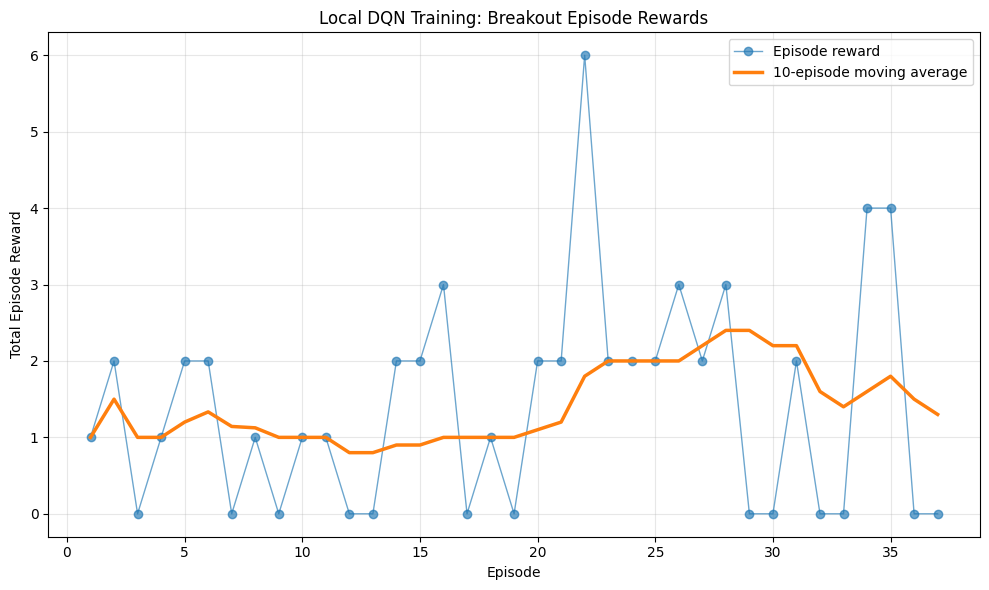

EPISODE REWARD ANALYSIS
Completed episodes          : 37
Overall mean reward         : 1.4324
Median episode reward       : 1.0000
Minimum episode reward      : 0.0000
Maximum episode reward      : 6.0000
First 10 mean reward       : 1.0000
Final 10 mean reward       : 1.3000
Early-to-late reward change : +0.3000
Final moving-average reward : 1.3000
Plot saved to               : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\outputs\local_episode_reward_curve.png
File exists                 : True

Reward visualization and validation completed successfully.


In [20]:
# Analyze and visualize episode rewards from the local DQN training run.

reward_analysis_dataframe = (
    episode_metrics_dataframe.copy()
)

rolling_window = min(
    10,
    len(reward_analysis_dataframe),
)

reward_analysis_dataframe["rolling_mean_reward"] = (
    reward_analysis_dataframe["episode_reward"]
    .rolling(
        window=rolling_window,
        min_periods=1,
    )
    .mean()
)


# ---------------------------------------------------------
# Calculate early and late performance summaries
# ---------------------------------------------------------

comparison_window = min(
    10,
    len(reward_analysis_dataframe),
)

first_window_mean_reward = float(
    reward_analysis_dataframe[
        "episode_reward"
    ]
    .head(comparison_window)
    .mean()
)

final_window_mean_reward = float(
    reward_analysis_dataframe[
        "episode_reward"
    ]
    .tail(comparison_window)
    .mean()
)

reward_change = (
    final_window_mean_reward
    - first_window_mean_reward
)


# ---------------------------------------------------------
# Plot episode rewards and rolling mean
# ---------------------------------------------------------

reward_plot_path = (
    outputs_directory
    / "local_episode_reward_curve.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    reward_analysis_dataframe["episode"],
    reward_analysis_dataframe["episode_reward"],
    marker="o",
    linewidth=1,
    alpha=0.65,
    label="Episode reward",
)

plt.plot(
    reward_analysis_dataframe["episode"],
    reward_analysis_dataframe[
        "rolling_mean_reward"
    ],
    linewidth=2.5,
    label=f"{rolling_window}-episode moving average",
)

plt.xlabel("Episode")
plt.ylabel("Total Episode Reward")
plt.title("Local DQN Training: Breakout Episode Rewards")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    reward_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------
# Display reward statistics
# ---------------------------------------------------------

print("=" * 72)
print("EPISODE REWARD ANALYSIS")
print("=" * 72)
print(
    f"Completed episodes          : "
    f"{len(reward_analysis_dataframe)}"
)
print(
    f"Overall mean reward         : "
    f"{reward_analysis_dataframe['episode_reward'].mean():.4f}"
)
print(
    f"Median episode reward       : "
    f"{reward_analysis_dataframe['episode_reward'].median():.4f}"
)
print(
    f"Minimum episode reward      : "
    f"{reward_analysis_dataframe['episode_reward'].min():.4f}"
)
print(
    f"Maximum episode reward      : "
    f"{reward_analysis_dataframe['episode_reward'].max():.4f}"
)
print(
    f"First {comparison_window} mean reward       : "
    f"{first_window_mean_reward:.4f}"
)
print(
    f"Final {comparison_window} mean reward       : "
    f"{final_window_mean_reward:.4f}"
)
print(
    f"Early-to-late reward change : "
    f"{reward_change:+.4f}"
)
print(
    f"Final moving-average reward : "
    f"{reward_analysis_dataframe['rolling_mean_reward'].iloc[-1]:.4f}"
)
print(f"Plot saved to               : {reward_plot_path}")
print(f"File exists                 : {reward_plot_path.exists()}")


# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

assert reward_plot_path.exists()

assert len(
    reward_analysis_dataframe[
        "rolling_mean_reward"
    ]
) == len(
    reward_analysis_dataframe
)

assert np.isfinite(
    reward_analysis_dataframe[
        "rolling_mean_reward"
    ]
).all()


print("\nReward visualization and validation completed successfully.")

## 23. Training Loss Analysis

The DQN training loss measures the difference between the online network's
predicted Q-values and the Bellman targets calculated using the target network.

Because each optimization update samples a random replay-buffer minibatch, the
raw loss may fluctuate considerably. A moving average is therefore included to
show the broader optimization trend.

A decreasing and finite loss suggests that the network is learning to fit its
Bellman targets. However, a low loss does not necessarily indicate a strong
gameplay policy. Episode rewards and evaluation performance must also improve
before convergence can be claimed.

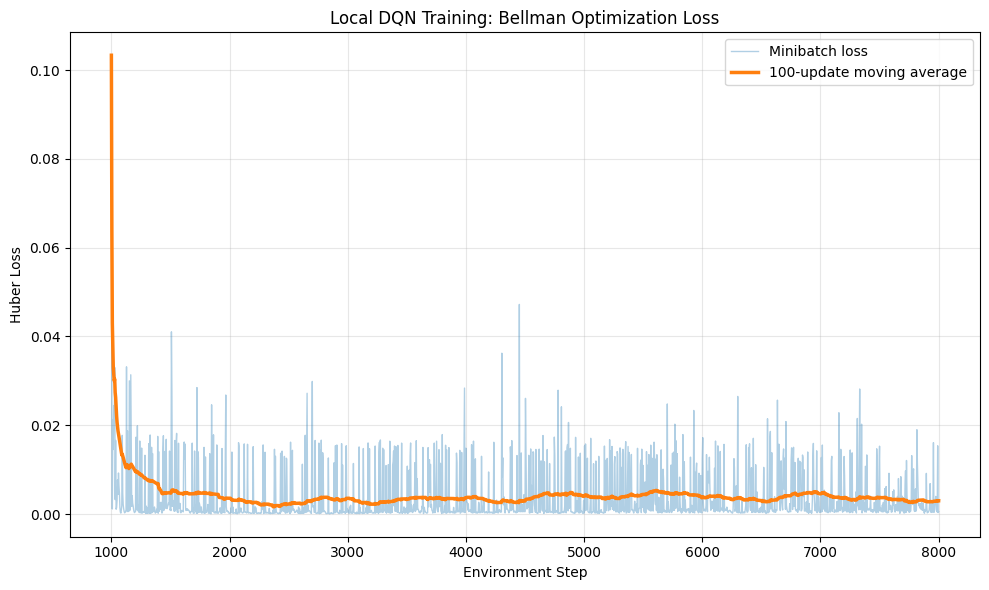

TRAINING LOSS ANALYSIS
Optimization updates       : 1,751
Overall mean loss          : 0.003766
Median loss                : 0.000765
Minimum loss               : 0.000061
Maximum loss               : 0.103340
First 100 mean loss      : 0.006833
Final 100 mean loss      : 0.003008
Early-to-late loss change  : -0.003825
Final moving-average loss  : 0.003008
Plot saved to              : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\outputs\local_training_loss_curve.png
File exists                : True

Training-loss visualization and validation completed successfully.


In [21]:
# Analyze and visualize the DQN optimization loss.

loss_analysis_dataframe = (
    update_metrics_dataframe.copy()
)

loss_rolling_window = min(
    100,
    len(loss_analysis_dataframe),
)

loss_analysis_dataframe["rolling_mean_loss"] = (
    loss_analysis_dataframe["loss"]
    .rolling(
        window=loss_rolling_window,
        min_periods=1,
    )
    .mean()
)


# ---------------------------------------------------------
# Compare early and late optimization loss
# ---------------------------------------------------------

loss_comparison_window = min(
    100,
    len(loss_analysis_dataframe),
)

first_window_mean_loss = float(
    loss_analysis_dataframe["loss"]
    .head(loss_comparison_window)
    .mean()
)

final_window_mean_loss = float(
    loss_analysis_dataframe["loss"]
    .tail(loss_comparison_window)
    .mean()
)

loss_change = (
    final_window_mean_loss
    - first_window_mean_loss
)


# ---------------------------------------------------------
# Plot raw and rolling-average loss
# ---------------------------------------------------------

loss_plot_path = (
    outputs_directory
    / "local_training_loss_curve.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    loss_analysis_dataframe["environment_step"],
    loss_analysis_dataframe["loss"],
    linewidth=1,
    alpha=0.35,
    label="Minibatch loss",
)

plt.plot(
    loss_analysis_dataframe["environment_step"],
    loss_analysis_dataframe["rolling_mean_loss"],
    linewidth=2.5,
    label=f"{loss_rolling_window}-update moving average",
)

plt.xlabel("Environment Step")
plt.ylabel("Huber Loss")
plt.title("Local DQN Training: Bellman Optimization Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    loss_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------
# Display loss statistics
# ---------------------------------------------------------

print("=" * 72)
print("TRAINING LOSS ANALYSIS")
print("=" * 72)
print(
    f"Optimization updates       : "
    f"{len(loss_analysis_dataframe):,}"
)
print(
    f"Overall mean loss          : "
    f"{loss_analysis_dataframe['loss'].mean():.6f}"
)
print(
    f"Median loss                : "
    f"{loss_analysis_dataframe['loss'].median():.6f}"
)
print(
    f"Minimum loss               : "
    f"{loss_analysis_dataframe['loss'].min():.6f}"
)
print(
    f"Maximum loss               : "
    f"{loss_analysis_dataframe['loss'].max():.6f}"
)
print(
    f"First {loss_comparison_window} mean loss      : "
    f"{first_window_mean_loss:.6f}"
)
print(
    f"Final {loss_comparison_window} mean loss      : "
    f"{final_window_mean_loss:.6f}"
)
print(
    f"Early-to-late loss change  : "
    f"{loss_change:+.6f}"
)
print(
    f"Final moving-average loss  : "
    f"{loss_analysis_dataframe['rolling_mean_loss'].iloc[-1]:.6f}"
)
print(f"Plot saved to              : {loss_plot_path}")
print(f"File exists                : {loss_plot_path.exists()}")


# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

assert loss_plot_path.exists()

assert np.isfinite(
    loss_analysis_dataframe["loss"]
).all()

assert np.isfinite(
    loss_analysis_dataframe["rolling_mean_loss"]
).all()

assert (
    loss_analysis_dataframe["loss"] >= 0
).all()


print("\nTraining-loss visualization and validation completed successfully.")

## 24. Q-Value and Temporal-Difference Error Analysis

The predicted Q-value represents the online network's estimate of the expected
discounted return for the action stored in each sampled transition.

The target Q-value combines the immediate reward with the discounted maximum
next-state value produced by the target network.

The temporal-difference error measures the difference between these two values.
A smaller and stable TD error indicates that the online network is becoming
more consistent with its Bellman targets.

These metrics are optimization diagnostics. They must be considered together
with episode rewards because accurate Bellman-target fitting does not by itself
guarantee strong gameplay performance.

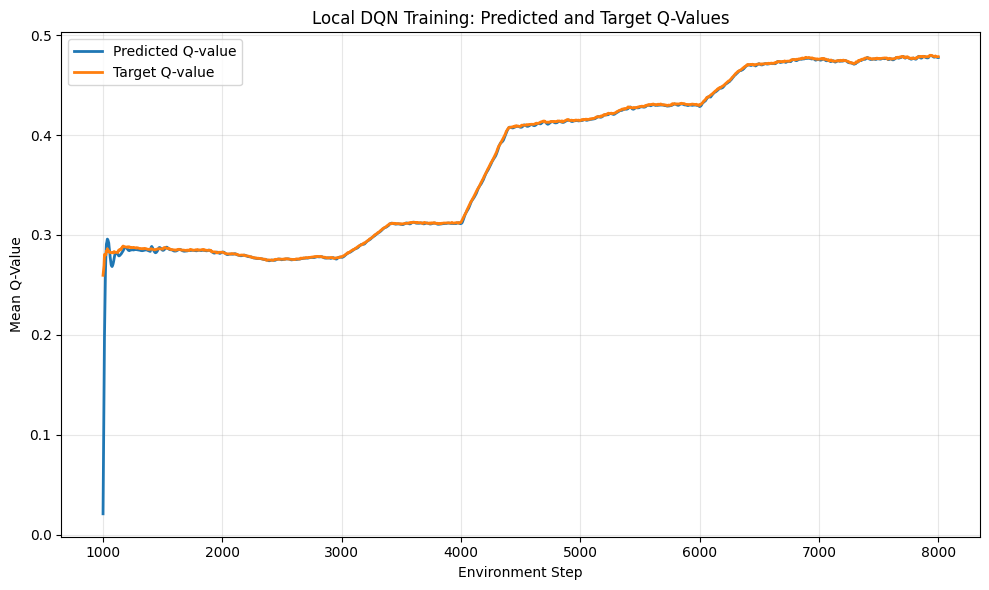

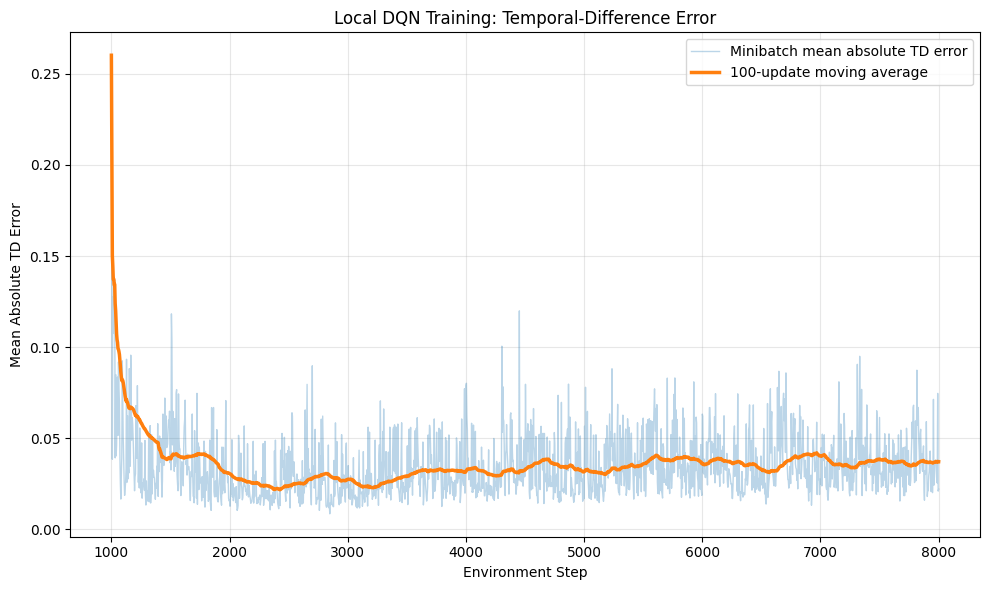

Q-VALUE AND TD-ERROR ANALYSIS
First 100 mean predicted Q : 0.283504
Final 100 mean predicted Q : 0.477567
First 100 mean target Q    : 0.285617
Final 100 mean target Q    : 0.478462
First 100 mean TD error    : 0.047499
Final 100 mean TD error    : 0.037163
TD-error change                         : -0.010336
Q-value plot saved to                   : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\outputs\local_q_value_trends.png
TD-error plot saved to                  : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\outputs\local_td_error_curve.png
Q-value plot exists                     : True
TD-error plot exists                    : True

Q-value and TD-error analysis completed successfully.


In [22]:
# Visualize predicted Q-values, Bellman targets, and TD errors.

value_analysis_dataframe = update_metrics_dataframe.copy()

value_rolling_window = min(
    100,
    len(value_analysis_dataframe),
)

value_analysis_dataframe["rolling_predicted_q"] = (
    value_analysis_dataframe["mean_predicted_q_value"]
    .rolling(
        window=value_rolling_window,
        min_periods=1,
    )
    .mean()
)

value_analysis_dataframe["rolling_target_q"] = (
    value_analysis_dataframe["mean_target_q_value"]
    .rolling(
        window=value_rolling_window,
        min_periods=1,
    )
    .mean()
)

value_analysis_dataframe["rolling_td_error"] = (
    value_analysis_dataframe["mean_absolute_td_error"]
    .rolling(
        window=value_rolling_window,
        min_periods=1,
    )
    .mean()
)


# ---------------------------------------------------------
# Plot predicted and target Q-values
# ---------------------------------------------------------

q_value_plot_path = (
    outputs_directory
    / "local_q_value_trends.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    value_analysis_dataframe["environment_step"],
    value_analysis_dataframe["rolling_predicted_q"],
    linewidth=2,
    label="Predicted Q-value",
)

plt.plot(
    value_analysis_dataframe["environment_step"],
    value_analysis_dataframe["rolling_target_q"],
    linewidth=2,
    label="Target Q-value",
)

plt.xlabel("Environment Step")
plt.ylabel("Mean Q-Value")
plt.title("Local DQN Training: Predicted and Target Q-Values")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    q_value_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------
# Plot temporal-difference error
# ---------------------------------------------------------

td_error_plot_path = (
    outputs_directory
    / "local_td_error_curve.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    value_analysis_dataframe["environment_step"],
    value_analysis_dataframe["mean_absolute_td_error"],
    linewidth=1,
    alpha=0.30,
    label="Minibatch mean absolute TD error",
)

plt.plot(
    value_analysis_dataframe["environment_step"],
    value_analysis_dataframe["rolling_td_error"],
    linewidth=2.5,
    label=f"{value_rolling_window}-update moving average",
)

plt.xlabel("Environment Step")
plt.ylabel("Mean Absolute TD Error")
plt.title("Local DQN Training: Temporal-Difference Error")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    td_error_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------
# Compare early and late Q-value and TD-error behavior
# ---------------------------------------------------------

diagnostic_window = min(
    100,
    len(value_analysis_dataframe),
)

early_predicted_q = float(
    value_analysis_dataframe["mean_predicted_q_value"]
    .head(diagnostic_window)
    .mean()
)

late_predicted_q = float(
    value_analysis_dataframe["mean_predicted_q_value"]
    .tail(diagnostic_window)
    .mean()
)

early_target_q = float(
    value_analysis_dataframe["mean_target_q_value"]
    .head(diagnostic_window)
    .mean()
)

late_target_q = float(
    value_analysis_dataframe["mean_target_q_value"]
    .tail(diagnostic_window)
    .mean()
)

early_td_error = float(
    value_analysis_dataframe["mean_absolute_td_error"]
    .head(diagnostic_window)
    .mean()
)

late_td_error = float(
    value_analysis_dataframe["mean_absolute_td_error"]
    .tail(diagnostic_window)
    .mean()
)


print("=" * 76)
print("Q-VALUE AND TD-ERROR ANALYSIS")
print("=" * 76)
print(
    f"First {diagnostic_window} mean predicted Q : "
    f"{early_predicted_q:.6f}"
)
print(
    f"Final {diagnostic_window} mean predicted Q : "
    f"{late_predicted_q:.6f}"
)
print(
    f"First {diagnostic_window} mean target Q    : "
    f"{early_target_q:.6f}"
)
print(
    f"Final {diagnostic_window} mean target Q    : "
    f"{late_target_q:.6f}"
)
print(
    f"First {diagnostic_window} mean TD error    : "
    f"{early_td_error:.6f}"
)
print(
    f"Final {diagnostic_window} mean TD error    : "
    f"{late_td_error:.6f}"
)
print(
    f"TD-error change                         : "
    f"{late_td_error - early_td_error:+.6f}"
)
print(f"Q-value plot saved to                   : {q_value_plot_path}")
print(f"TD-error plot saved to                  : {td_error_plot_path}")
print(f"Q-value plot exists                     : {q_value_plot_path.exists()}")
print(f"TD-error plot exists                    : {td_error_plot_path.exists()}")


# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

required_value_columns = [
    "mean_predicted_q_value",
    "mean_target_q_value",
    "mean_absolute_td_error",
    "rolling_predicted_q",
    "rolling_target_q",
    "rolling_td_error",
]

for column_name in required_value_columns:
    assert np.isfinite(
        value_analysis_dataframe[column_name]
    ).all()

assert (
    value_analysis_dataframe[
        "mean_absolute_td_error"
    ] >= 0
).all()

assert q_value_plot_path.exists()
assert td_error_plot_path.exists()


print("\nQ-value and TD-error analysis completed successfully.")

## 25. Trained-Agent Evaluation

Training metrics describe the optimization process, but the learned policy
must also be tested independently.

The trained DQN is evaluated over ten new Breakout episodes using an epsilon
value of 0.05. This means the agent primarily selects the action with the
highest predicted Q-value while retaining a small amount of exploration.

For comparison, a random-action policy is evaluated over the same number of
episodes.

The evaluation records:

- episode reward,
- episode length,
- mean and standard deviation of reward,
- best observed reward,
- trained-agent performance relative to the random baseline.

A gameplay frame from the best trained-agent episode is saved for inclusion in
the project report.

RANDOM BASELINE EVALUATION
Random baseline  | Episode  1/10 | Reward   2.0 | Length  185
Random baseline  | Episode  2/10 | Reward   1.0 | Length  171
Random baseline  | Episode  3/10 | Reward   2.0 | Length  219
Random baseline  | Episode  4/10 | Reward   3.0 | Length  228
Random baseline  | Episode  5/10 | Reward   0.0 | Length  125
Random baseline  | Episode  6/10 | Reward   1.0 | Length  170
Random baseline  | Episode  7/10 | Reward   0.0 | Length  123
Random baseline  | Episode  8/10 | Reward   1.0 | Length  173
Random baseline  | Episode  9/10 | Reward   1.0 | Length  171
Random baseline  | Episode 10/10 | Reward   0.0 | Length  123

TRAINED DQN EVALUATION
Trained DQN      | Episode  1/10 | Reward   1.0 | Length  153
Trained DQN      | Episode  2/10 | Reward   0.0 | Length  125
Trained DQN      | Episode  3/10 | Reward   6.0 | Length  367
Trained DQN      | Episode  4/10 | Reward   1.0 | Length  153
Trained DQN      | Episode  5/10 | Reward   1.0 | Length  171
Trained DQN      | 

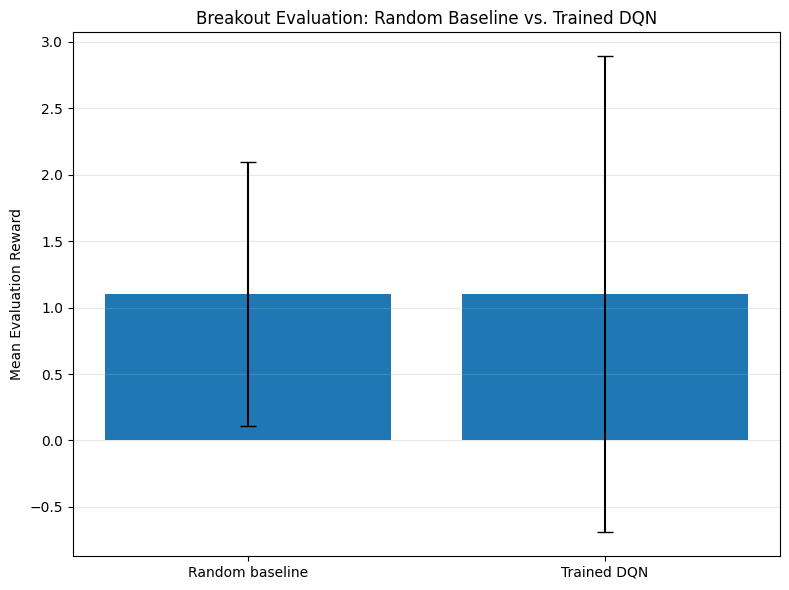

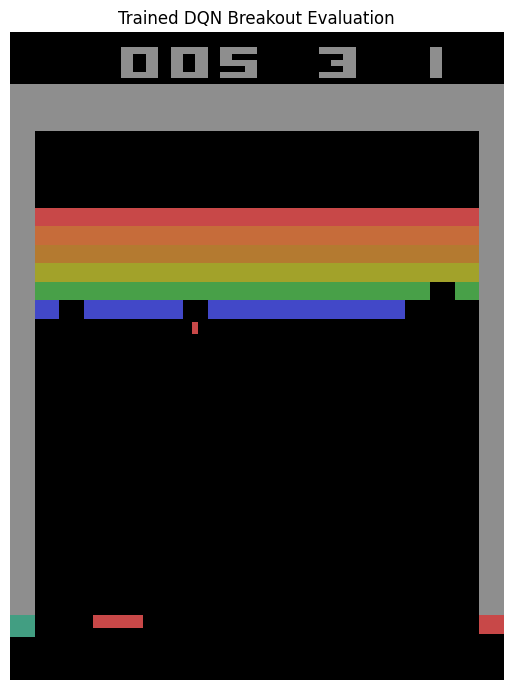


EVALUATION SUMMARY
         policy  mean_reward  reward_standard_deviation  minimum_reward  maximum_reward  mean_episode_length
Random baseline       1.1000                     0.9944          0.0000          3.0000             168.8000
    Trained DQN       1.1000                     1.7920          0.0000          6.0000             166.8000

Random-policy mean reward : 1.1000
Trained-DQN mean reward   : 1.1000
Reward difference         : +0.0000
Evaluation metrics saved  : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\outputs\local_evaluation_metrics.csv
Evaluation plot saved     : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\outputs\local_evaluation_comparison.png
Gameplay frame saved      : c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_DQN_Atari_Game\screenshots\trained_dqn_best_evaluation_frame.png

Evaluation

In [23]:
# Evaluate the trained DQN against a random-action baseline.

def evaluate_breakout_policy(
    network: nn.Module | None,
    policy_name: str,
    number_of_episodes: int,
    evaluation_epsilon: float,
    target_device: torch.device,
    random_seed: int,
    use_random_policy: bool = False,
    save_best_frame: bool = False,
):
    """
    Evaluate either a trained DQN or a random policy in Breakout.

    Parameters
    ----------
    network : nn.Module or None
        Trained DQN. Use None for a random policy.

    policy_name : str
        Name used to identify the evaluated policy.

    number_of_episodes : int
        Number of complete episodes to evaluate.

    evaluation_epsilon : float
        Exploration probability used by the trained policy.

    target_device : torch.device
        Device used for DQN inference.

    random_seed : int
        Base seed for reproducible evaluation.

    use_random_policy : bool
        When True, select actions uniformly at random.

    save_best_frame : bool
        When True, retain a frame from the best-scoring episode.

    Returns
    -------
    pd.DataFrame
        Episode-level evaluation results.

    np.ndarray or None
        Best gameplay frame when requested.
    """

    evaluation_environment = create_atari_environment(
        render_mode="rgb_array",
        seed=random_seed,
    )

    evaluation_generator = np.random.default_rng(
        random_seed
    )

    if network is not None:
        network.eval()

    evaluation_records = []

    best_episode_reward = -np.inf
    best_gameplay_frame = None

    try:
        for episode_index in range(number_of_episodes):
            state, reset_info = evaluation_environment.reset(
                seed=random_seed + episode_index
            )

            episode_reward = 0.0
            episode_length = 0
            episode_finished = False

            # Breakout requires FIRE to launch the ball.
            state, reward, terminated, truncated, step_info = (
                evaluation_environment.step(1)
            )

            episode_reward += float(reward)
            episode_length += 1

            episode_finished = bool(
                terminated or truncated
            )

            previous_lives = step_info.get(
                "lives",
                None,
            )

            highest_recorded_reward = episode_reward

            episode_snapshot = evaluation_environment.render()

            while not episode_finished:
                if use_random_policy:
                    selected_action = int(
                        evaluation_generator.integers(
                            number_of_actions
                        )
                    )
                else:
                    (
                        selected_action,
                        decision_mode,
                        selected_q_value,
                    ) = select_epsilon_greedy_action(
                        state=np.asarray(
                            state,
                            dtype=np.uint8,
                        ),
                        network=network,
                        number_of_actions=number_of_actions,
                        epsilon=evaluation_epsilon,
                        target_device=target_device,
                        random_generator=evaluation_generator,
                    )

                (
                    next_state,
                    reward,
                    terminated,
                    truncated,
                    step_info,
                ) = evaluation_environment.step(
                    selected_action
                )

                episode_reward += float(reward)
                episode_length += 1

                current_frame = evaluation_environment.render()

                # Retain a frame whenever the episode achieves
                # a new cumulative reward.
                if episode_reward > highest_recorded_reward:
                    highest_recorded_reward = episode_reward
                    episode_snapshot = current_frame.copy()

                episode_finished = bool(
                    terminated or truncated
                )

                current_lives = step_info.get(
                    "lives",
                    previous_lives,
                )

                # Launch the ball again after losing a life.
                if (
                    not episode_finished
                    and previous_lives is not None
                    and current_lives is not None
                    and current_lives < previous_lives
                ):
                    (
                        next_state,
                        fire_reward,
                        terminated,
                        truncated,
                        step_info,
                    ) = evaluation_environment.step(1)

                    episode_reward += float(fire_reward)
                    episode_length += 1

                    episode_finished = bool(
                        terminated or truncated
                    )

                    current_lives = step_info.get(
                        "lives",
                        current_lives,
                    )

                previous_lives = current_lives
                state = next_state

            evaluation_records.append(
                {
                    "policy": policy_name,
                    "episode": episode_index + 1,
                    "episode_reward": episode_reward,
                    "episode_length": episode_length,
                }
            )

            if (
                save_best_frame
                and episode_reward > best_episode_reward
            ):
                best_episode_reward = episode_reward
                best_gameplay_frame = episode_snapshot.copy()

            print(
                f"{policy_name:<16} | "
                f"Episode {episode_index + 1:>2}/"
                f"{number_of_episodes} | "
                f"Reward {episode_reward:>5.1f} | "
                f"Length {episode_length:>4}"
            )

    finally:
        evaluation_environment.close()

    return (
        pd.DataFrame(evaluation_records),
        best_gameplay_frame,
    )


# ---------------------------------------------------------
# Evaluate the random baseline
# ---------------------------------------------------------

print("=" * 76)
print("RANDOM BASELINE EVALUATION")
print("=" * 76)

random_evaluation_dataframe, _ = evaluate_breakout_policy(
    network=None,
    policy_name="Random baseline",
    number_of_episodes=10,
    evaluation_epsilon=1.0,
    target_device=device,
    random_seed=RANDOM_SEED + 100,
    use_random_policy=True,
    save_best_frame=False,
)


# ---------------------------------------------------------
# Evaluate the trained DQN
# ---------------------------------------------------------

print("\n" + "=" * 76)
print("TRAINED DQN EVALUATION")
print("=" * 76)

trained_evaluation_dataframe, best_evaluation_frame = (
    evaluate_breakout_policy(
        network=local_training_result.online_network,
        policy_name="Trained DQN",
        number_of_episodes=10,
        evaluation_epsilon=0.05,
        target_device=device,
        random_seed=RANDOM_SEED + 200,
        use_random_policy=False,
        save_best_frame=True,
    )
)


# ---------------------------------------------------------
# Combine and save evaluation results
# ---------------------------------------------------------

evaluation_dataframe = pd.concat(
    [
        random_evaluation_dataframe,
        trained_evaluation_dataframe,
    ],
    ignore_index=True,
)

evaluation_metrics_path = (
    outputs_directory
    / "local_evaluation_metrics.csv"
)

evaluation_dataframe.to_csv(
    evaluation_metrics_path,
    index=False,
)


# ---------------------------------------------------------
# Calculate summary statistics
# ---------------------------------------------------------

evaluation_summary_dataframe = (
    evaluation_dataframe
    .groupby("policy")
    .agg(
        mean_reward=("episode_reward", "mean"),
        reward_standard_deviation=("episode_reward", "std"),
        minimum_reward=("episode_reward", "min"),
        maximum_reward=("episode_reward", "max"),
        mean_episode_length=("episode_length", "mean"),
    )
    .reset_index()
)

random_mean_reward = float(
    random_evaluation_dataframe[
        "episode_reward"
    ].mean()
)

trained_mean_reward = float(
    trained_evaluation_dataframe[
        "episode_reward"
    ].mean()
)

evaluation_reward_difference = (
    trained_mean_reward
    - random_mean_reward
)


# ---------------------------------------------------------
# Save evaluation comparison plot
# ---------------------------------------------------------

evaluation_plot_path = (
    outputs_directory
    / "local_evaluation_comparison.png"
)

plot_labels = [
    "Random baseline",
    "Trained DQN",
]

plot_means = [
    random_mean_reward,
    trained_mean_reward,
]

plot_standard_deviations = [
    float(
        random_evaluation_dataframe[
            "episode_reward"
        ].std()
    ),
    float(
        trained_evaluation_dataframe[
            "episode_reward"
        ].std()
    ),
]

plt.figure(figsize=(8, 6))

plt.bar(
    plot_labels,
    plot_means,
    yerr=plot_standard_deviations,
    capsize=6,
)

plt.ylabel("Mean Evaluation Reward")
plt.title("Breakout Evaluation: Random Baseline vs. Trained DQN")
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.tight_layout()

plt.savefig(
    evaluation_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------
# Save the best gameplay screenshot
# ---------------------------------------------------------

best_gameplay_path = (
    screenshots_directory
    / "trained_dqn_best_evaluation_frame.png"
)

if best_evaluation_frame is not None:
    plt.figure(figsize=(6, 7))
    plt.imshow(best_evaluation_frame)
    plt.title("Trained DQN Breakout Evaluation")
    plt.axis("off")
    plt.tight_layout()

    plt.savefig(
        best_gameplay_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()


# ---------------------------------------------------------
# Display evaluation results
# ---------------------------------------------------------

print("\n" + "=" * 76)
print("EVALUATION SUMMARY")
print("=" * 76)

print(
    evaluation_summary_dataframe.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

print(
    f"\nRandom-policy mean reward : "
    f"{random_mean_reward:.4f}"
)

print(
    f"Trained-DQN mean reward   : "
    f"{trained_mean_reward:.4f}"
)

print(
    f"Reward difference         : "
    f"{evaluation_reward_difference:+.4f}"
)

print(
    f"Evaluation metrics saved  : "
    f"{evaluation_metrics_path}"
)

print(
    f"Evaluation plot saved     : "
    f"{evaluation_plot_path}"
)

print(
    f"Gameplay frame saved      : "
    f"{best_gameplay_path}"
)


# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

assert len(random_evaluation_dataframe) == 10
assert len(trained_evaluation_dataframe) == 10

assert np.isfinite(
    evaluation_dataframe["episode_reward"]
).all()

assert np.isfinite(
    evaluation_dataframe["episode_length"]
).all()

assert evaluation_metrics_path.exists()
assert evaluation_plot_path.exists()
assert best_gameplay_path.exists()


print("\nEvaluation and gameplay capture completed successfully.")

## 26. Final Project Output Verification

The final section verifies that the project generated all required artifacts.

The completed implementation includes the Atari environment, visual
preprocessing, convolutional DQN, experience replay, online and target
networks, epsilon-greedy exploration, Bellman learning updates, checkpointing,
performance tracking, training visualizations, evaluation results, and gameplay
screenshots.

The short local run demonstrated stable optimization and a small improvement in
the training reward trend. However, the trained policy did not outperform the
random baseline in mean evaluation reward. Therefore, the results support
successful implementation of the DQN pipeline but do not establish full
convergence.

In [24]:
# Verify and summarize all final project artifacts.

final_required_artifacts = {
    "Notebook": project_root / "DQN_Atari_Game.ipynb",
    "Final model checkpoint":
        checkpoints_directory / "breakout_dqn_local_final.pt",
    "Episode metrics":
        outputs_directory / "breakout_dqn_local_episode_metrics.csv",
    "Update metrics":
        outputs_directory / "breakout_dqn_local_update_metrics.csv",
    "Training summary":
        outputs_directory / "breakout_dqn_local_summary.json",
    "Epsilon schedule":
        outputs_directory / "epsilon_schedule.png",
    "Reward curve":
        outputs_directory / "local_episode_reward_curve.png",
    "Loss curve":
        outputs_directory / "local_training_loss_curve.png",
    "Q-value trends":
        outputs_directory / "local_q_value_trends.png",
    "TD-error curve":
        outputs_directory / "local_td_error_curve.png",
    "Evaluation metrics":
        outputs_directory / "local_evaluation_metrics.csv",
    "Evaluation comparison":
        outputs_directory / "local_evaluation_comparison.png",
    "Raw Atari frame":
        screenshots_directory / "raw_breakout_frame.png",
    "Stacked frames":
        screenshots_directory / "preprocessed_stacked_frames.png",
    "Evaluation gameplay frame":
        screenshots_directory / "trained_dqn_best_evaluation_frame.png",
}


artifact_records = []

for artifact_name, artifact_path in final_required_artifacts.items():
    artifact_exists = artifact_path.exists()

    artifact_size_mb = (
        artifact_path.stat().st_size / (1024 ** 2)
        if artifact_exists
        else 0.0
    )

    artifact_records.append(
        {
            "artifact": artifact_name,
            "path": str(artifact_path),
            "exists": artifact_exists,
            "size_mb": artifact_size_mb,
        }
    )


artifact_inventory_dataframe = pd.DataFrame(
    artifact_records
)


# Create the final project summary.
final_project_summary = {
    "project": "DQN on Atari Breakout",
    "environment": ENVIRONMENT_ID,
    "runtime": runtime_environment,
    "device": str(device),
    "training_steps":
        local_training_summary["total_environment_steps"],
    "approximate_atari_frames":
        local_training_summary["approximate_emulator_frames"],
    "completed_episodes":
        local_training_summary["completed_episodes"],
    "optimization_updates":
        local_training_summary["optimization_updates"],
    "target_synchronizations":
        local_training_summary["target_synchronizations"],
    "mean_training_reward":
        local_training_summary["mean_episode_reward"],
    "best_training_reward":
        local_training_summary["best_episode_reward"],
    "final_10_episode_mean_reward":
        local_training_summary["final_ten_mean_reward"],
    "first_10_episode_mean_reward":
        first_window_mean_reward,
    "training_reward_change":
        reward_change,
    "first_100_update_mean_loss":
        first_window_mean_loss,
    "final_100_update_mean_loss":
        final_window_mean_loss,
    "first_100_update_mean_td_error":
        early_td_error,
    "final_100_update_mean_td_error":
        late_td_error,
    "random_baseline_mean_reward":
        random_mean_reward,
    "trained_dqn_mean_reward":
        trained_mean_reward,
    "evaluation_reward_difference":
        evaluation_reward_difference,
    "convergence_conclusion": (
        "The implementation was numerically stable and the training "
        "reward showed limited improvement, but the trained policy did "
        "not outperform the random baseline in mean evaluation reward. "
        "Stable convergence was not demonstrated during the short local run."
    ),
}


final_summary_path = (
    outputs_directory / "final_project_summary.json"
)

with open(
    final_summary_path,
    "w",
    encoding="utf-8",
) as final_summary_file:
    json.dump(
        final_project_summary,
        final_summary_file,
        indent=4,
    )


print("=" * 78)
print("FINAL PROJECT ARTIFACT INVENTORY")
print("=" * 78)

print(
    artifact_inventory_dataframe[
        ["artifact", "exists", "size_mb"]
    ].to_string(
        index=False,
        formatters={
            "size_mb": lambda value: f"{value:.3f}",
        },
    )
)


missing_artifacts = artifact_inventory_dataframe.loc[
    ~artifact_inventory_dataframe["exists"],
    "artifact",
].tolist()


print("\n" + "=" * 78)
print("FINAL PROJECT RESULT")
print("=" * 78)
print(
    f"Training reward change     : "
    f"{reward_change:+.4f}"
)
print(
    f"Loss change                : "
    f"{loss_change:+.6f}"
)
print(
    f"TD-error change            : "
    f"{late_td_error - early_td_error:+.6f}"
)
print(
    f"Random evaluation reward   : "
    f"{random_mean_reward:.4f}"
)
print(
    f"Trained evaluation reward  : "
    f"{trained_mean_reward:.4f}"
)
print(
    f"Evaluation difference      : "
    f"{evaluation_reward_difference:+.4f}"
)
print(
    f"Final summary saved to     : "
    f"{final_summary_path}"
)


if missing_artifacts:
    print(
        f"\nMissing artifacts          : "
        f"{missing_artifacts}"
    )
else:
    print(
        "\nAll required notebook artifacts were generated successfully."
    )


assert not missing_artifacts
assert final_summary_path.exists()

print("\nDQN Atari notebook implementation is complete.")

FINAL PROJECT ARTIFACT INVENTORY
                 artifact  exists size_mb
                 Notebook    True   0.669
   Final model checkpoint    True  25.828
          Episode metrics    True   0.001
           Update metrics    True   0.178
         Training summary    True   0.001
         Epsilon schedule    True   0.045
             Reward curve    True   0.097
               Loss curve    True   0.101
           Q-value trends    True   0.063
           TD-error curve    True   0.125
       Evaluation metrics    True   0.001
    Evaluation comparison    True   0.032
          Raw Atari frame    True   0.011
           Stacked frames    True   0.019
Evaluation gameplay frame    True   0.011

FINAL PROJECT RESULT
Training reward change     : +0.3000
Loss change                : -0.003825
TD-error change            : -0.010336
Random evaluation reward   : 1.1000
Trained evaluation reward  : 1.1000
Evaluation difference      : +0.0000
Final summary saved to     : c:\Users\dubey\Docum